# Download dei dati

In [ ]:
#@title Righe da decommentare prima della consegna: fanno download sulla RAM di colab
# import gdown
# import os
# !mkdir -p processed_data
# fn_back=r"processed_data/events_LHCO2020_backgroundMC_Pythia.h5"
# url = "https://drive.google.com/uc?id=13ToB6s9MlDtDz2wbt2TxPxcNxzDrmTep"
# gdown.download(url, "events_LHCO2020_backgroundMC_Pythia.h5", quiet=False, )

# fn_signal1= r"processed_data/events_LHCO2020_BlackBox1.h5"
# url_signal1="https://drive.google.com/uc?export=download&id=1jeAtx6V7R-VfDQMwgQUt5GCbPjDbVc8w"
# gdown.download(url_signal1, fn_signal1, quiet=False)

# fn_signal2= r"processed_data/events_LHCO2020_BlackBox3.h5"
# url_signal2="https://drive.google.com/uc?export=download&id=1vOwsAvnZTC6XFCLbvUBwJWRyAtNZSLMx"
# gdown.download(url_signal2, fn_signal2, quiet=False)


## Download per noi: lavoriamo nella cartella "set dati machine learning"
Il dataset viene salvato nella cartella set dati machine learning/processed_data

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/set dati machine learning/processed_data', exist_ok=True)
os.chdir('/content/drive/MyDrive/set dati machine learning')

Mounted at /content/drive


### Use of google download  to download all the 3 file.h5 and file of masterkeys

In [ ]:
import gdown
fn_back=r"processed_data/events_LHCO2020_backgroundMC_Pythia.h5"
url = "https://drive.google.com/uc?id=13ToB6s9MlDtDz2wbt2TxPxcNxzDrmTep"
if not os.path.exists(fn_back):
  gdown.download(url, fn_back, quiet=False)

In [ ]:
fn_signal1= r"processed_data/events_LHCO2020_BlackBox1.h5"
url_signal1="https://drive.google.com/uc?export=download&id=1jeAtx6V7R-VfDQMwgQUt5GCbPjDbVc8w"
if not os.path.exists(fn_signal1):
  gdown.download(url_signal1, fn_signal1, quiet=False)
fn_signal1_m= r"processed_data/events_LHCO2020_BlackBox1.masterkey"
url_signal1_masterkey="https://drive.google.com/uc?export=download&id=1T_60d_IYZqWA4JDAmoVhVVzn2z1cqHHd"
if not os.path.exists(fn_signal1_m):
  gdown.download(url_signal1_masterkey, fn_signal1_m, quiet=False)


In [ ]:
#fn_signal2= r"processed_data/events_LHCO2020_BlackBox3.h5"
#url_signal2="https://drive.google.com/uc?export=download&id=1vOwsAvnZTC6XFCLbvUBwJWRyAtNZSLMx"
#if not os.path.exists(fn_signal2):
#  gdown.download(url_signal2, fn_signal2, quiet=False)
#fn_signal2_m= r"processed_data/events_LHCO2020_BlackBox3.masterkey"
#url_signal2_masterkey="https://drive.google.com/uc?export=download&id=1I039ZBBlUWNGeQxrcDru3gTGcT4wvRz8"
#if not os.path.exists(fn_signal2_m):
#  gdown.download(url_signal2_masterkey, fn_signal2_m, quiet=False)

# Apertura con pandas e conversione in numpy

In [ ]:
import pandas as pd
import numpy as np
N_back=50000 #100000
N_signal=10000 #20000
#tabelle (df) di pandas
df_background = pd.read_hdf(fn_back, stop=N_back)
print(df_background.shape)
df_signal1 = pd.read_hdf(fn_signal1, stop=N_signal)
print(df_signal1.shape)
#df_signal2 = pd.read_hdf(fn_signal2, stop=N_signal)
#print(df_signal2.shape)
# .values or .to_numpy() converts the DataFrame to a NumPy array
X_bg = df_background.values
X_test=df_signal1.values
#X_test2=df_signal2.values
print(type(X_bg), X_bg.shape)

(50000, 2100)
(10000, 2100)
<class 'numpy.ndarray'> (50000, 2100)


In [ ]:
#@title Visualizzazione di un evento
#import plotly.express as px

# Conversione rapida (senza normalizzazione)
#d = X_bg[0].reshape(-1, 3)
#p_x, p_y, p_z = d[:,0]*np.cos(d[:,2]), d[:,0]*np.sin(d[:,2]), d[:,0]*np.sinh(d[:,1])

# Plot interattivo
#fig = px.scatter_3d(x=p_x, y=p_y, z=p_z,labels={'x':'px', 'y':'py', 'z':'pz'}, opacity=0.5, width=600, height=300)
#fig.update_traces(marker=dict(size=4)),
#fig.show()

In [ ]:
import plotly.express as px
import numpy as np
import pandas as pd

# 1. Prendi l'evento e rimuovi lo zero-padding
# Assumiamo X_bg[0] sia la riga del dataset
event = X_bg[0].reshape(-1, 3)
mask = event[:, 0] > 0  # Prende solo particelle con pT > 0
clean_event = event[mask]

# 2. Estrazione coordinate (pT, eta, phi)
pt = clean_event[:, 0]
eta = clean_event[:, 1]
phi = clean_event[:, 2]

# 3. Conversione in componenti cartesiane per il plot 3D
px_coords = pt * np.cos(phi)
py_coords = pt * np.sin(phi)
pz_coords = pt * np.sinh(eta)
fig = px.scatter_3d(
    x=px_coords, y=py_coords, z=pz_coords,
    color=pt,  # Colora in base al pT per vedere i "core" dei jet
    labels={'x':'px (GeV)', 'y':'py (GeV)', 'z':'pz (GeV)', 'color':'pT'},
    title="Visualizzazione Evento LHCO (Particelle PF)",
    opacity=0.7,
    width=800, height=600
)

fig.update_traces(marker=dict(size=3))
fig.show()

# 1) Preprocessing:
Codice sostanziale **finito!**
Potrebbe essere aggiunto, con **titolo Analysis 5 or 6**:
1.   Plot di un jet, magari lo stesso di sopra
2.   Usare gli array **GIA CREATI** (OVVERO "np_leading_jets" con le coordinate dei jet, "np_j1", con le coordinate delle particelle per ogni evento (ogni evento ha un solo jet, soglia a 50 particelle)) per verificare che tutti i nostri jet soddisfano una certa soglia di massa invariante


Il paper dice:(In order to emulate the effect of a typical LHC
online event selection, only jet pairs with invariant mass
mjj > 1260 GeV are considered.)




In [ ]:
#@title Download of Fastjet library to clusterize the particles in jets
!pip install fastjet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 21.2 MB/s eta 0:00:00


In [ ]:
import fastjet
import awkward as ak  #Awkward Array
import vector
import matplotlib.pyplot as plt

In [ ]:
print(X_bg.shape)

(50000, 2100)


In [ ]:
def cinematic(j):
    """
    Input: j è un array dove:
    j[:,0] -> pT (momento trasversale)
    j[:,1] -> eta (pseudorapidità)
    j[:,2] -> phi (angolo azimutale)
    """
    # Estrazione componenti spaziali
    px = j[:, 0] * np.cos(j[:, 2])
    py = j[:, 0] * np.sin(j[:, 2])
    pz = j[:, 0] * np.sinh(j[:, 1])

    # Calcolo dell'energia (assumendo massa nulla o momento totale)
    # E = pT * cosh(eta)
    energia = j[:, 0] * np.cosh(j[:, 1])

    return px, py, pz, energia

In [ ]:
#@title Anti-kT function to select energetic jet
def antikT(X_data, R=1.0, pt_min=1200.0, max_constituents=50):
    N_events = len(X_data)
    # Prepariamo gli array di output: (N, 3) per i jet, (N, 100, 3) per i costituenti
    out_jets = []
    out_constits = []
    out_num_of_constits=[]

    jetdef = fastjet.JetDefinition(fastjet.antikt_algorithm, R)

    for i in range(N_events):
        # 1. Reshape e pulizia
        event = X_data[i].reshape(700, 3)
        mask = event[:, 0] > 0
        p_reali = event[mask]

        # 2. Creazione PseudoJets
        px,py,pz,e=cinematic(p_reali)

        pjet_list = [fastjet.PseudoJet(x, y, z, en) for x, y, z, en in zip(px, py, pz, e)]

        # 3. Clustering
        cluster = fastjet.ClusterSequence(pjet_list, jetdef)
        # Filtriamo per ptmin e anche per |eta| < 2.5 come richiesto dal challenge
        jets = cluster.inclusive_jets(pt_min)
        jets = [j for j in jets if abs(j.eta()) < 2.5]

        if len(jets) > 0:
            # Ordiniamo per pT e prendiamo il leading
            jets = sorted(jets, key=lambda x: x.pt(), reverse=True)
            lead_j = jets[0]
            consts = lead_j.constituents()
            consts = sorted(consts, key=lambda x: x.pt(), reverse=True)

            # Salviamo il jet (pt, eta, phi)
            out_jets.append([lead_j.pt(), lead_j.eta(), lead_j.phi_std()])

            # 4. Estrazione costituenti con PADDING a 100
            c_list = []
            for j in range(max_constituents):
                if j < len(consts):
                    c = consts[j]
                    c_list.append([c.pt(), c.eta(), c.phi_std()])
                else:
                    c_list.append([0.0, 0.0, 0.0]) # Padding
            out_constits.append(c_list)
            out_num_of_constits.append(len(consts))

            # Stampa di progressione
            # if i % 1000 == 0:
            #     print(f"Evento (ne stampo 1 ogni 1000) {i}: Jet pT={lead_j.pt():.1f}, Costituenti={len(consts)}")
        else:
            # Se l'evento non ha jet validi, potresti volerlo saltare o mettere zeri
            continue

    return np.array(out_jets), np.array(out_constits), np.array(out_num_of_constits)

In [ ]:
#@title Centering function (only for real particles, not for zero-padding ones)
def center_single_jet(jet_axis, constituents):
    """
    Centra i costituenti di un singolo jet rispetto al suo asse.

    Parametri:
    ----------
    jet_axis : np.array di shape (N, 3)
               Contiene [pt, eta, phi] del jet per ogni evento.
    constituents : np.array di shape (N, max_particles, 3)
                   Contiene [pt, eta, phi] dei costituenti.

    Ritorna:
    --------
    centered_constits : np.array (N, max_particles, 3) con eta e phi traslati.
    """
    # Copia dei dati per evitare side-effects
    centered_constits = np.copy(constituents)

    # 1. Estrazione coordinate del centro (espandiamo a (N, 1) per il broadcast)
    eta_jet = jet_axis[:, 1][:, np.newaxis]
    phi_jet = jet_axis[:, 2][:, np.newaxis]

    # 2. Maschera di validità: identifichiamo dove pt > 0 (escludiamo il padding)
    mask_real = centered_constits[:, :, 0] > 0

    # 3. Calcolo Delta Eta
    centered_constits[:, :, 1] = (centered_constits[:, :, 1] - eta_jet) * mask_real

    # 4. Calcolo Delta Phi con correzione periodica (range [-pi, pi])
    d_phi = centered_constits[:, :, 2] - phi_jet
    d_phi = (d_phi + np.pi) % (2 * np.pi) - np.pi
    centered_constits[:, :, 2] = d_phi * mask_real

    return centered_constits



In [ ]:
max_constituents=50

### background dataset: jet clustering and centering

In [ ]:
np_leading_jets, np_j1, np_numberofparticles = antikT(X_bg, max_constituents=max_constituents)
print(np_leading_jets.shape, np_j1.shape,  np_numberofparticles.shape)
#pd.DataFrame(np_j1[1,]).head() #rimuovere a fine lavori

(50000, 3) (50000, 50, 3) (50000,)


$(\eta, \phi) \xrightarrow{} (\Delta \eta, \Delta \phi)$  

In [ ]:
j1_background = center_single_jet(np_leading_jets,  np_j1)
print(j1_background.shape)

(50000, 50, 3)


### test dataset: jet clustering and centering

In [ ]:
np_leading_jets_test, np_j1_test, np_numberofparticles_test = antikT(X_test,  max_constituents=max_constituents)
print(np_leading_jets_test.shape, np_j1_test.shape, np_numberofparticles_test.shape)

(10000, 3) (10000, 50, 3) (10000,)


In [ ]:
print(X_bg.shape)
d = X_bg[0].reshape(-1, 3)
print(d.shape)
j=np_j1[0].reshape(-1,3)
print(j.shape)

(50000, 2100)
(700, 3)
(50, 3)


In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

# Conversione rapida
d = X_bg[0].reshape(-1, 3)
j=np_j1[0].reshape(-1,3)

# Calculate p_x, p_y, p_z for original event particles (d)
p_x_d, p_y_d, p_z_d, e_d = cinematic(d)

# Calculate p_x, p_y, p_z for jet constituents (j)
p_x_j, p_y_j, p_z_j, e_j=cinematic(j)

# Create DataFrames for plotting
df_d = pd.DataFrame({
    'px': p_x_d,
    'py': p_y_d,
    'pz': p_z_d,
    'type': 'Original Event Particles'
})

df_j = pd.DataFrame({
    'px': p_x_j,
    'py': p_y_j,
    'pz': p_z_j,
    'type': 'Jet Constituents'
})

# Concatenate the DataFrames
combined_df = pd.concat([df_d, df_j])

# Plot interattivo con colori diversi
fig = px.scatter_3d(
    combined_df,
    x='px', y='py', z='pz',
    color='type', # Use the 'type' column for coloring
    color_discrete_map={
        'Original Event Particles': 'blue',
        'Leading jet': 'red'
    },
    labels={'px':'px', 'py':'py', 'pz':'pz'},
    opacity=0.7, # Adjusted opacity for better visibility
    width=700, # Slightly increased width
    height=600, # Increased height for better 3D view
    title='Original Event Particles vs. Jet Constituents' # Added a title
)
fig.update_traces(marker=dict(size=4))
fig.show()

$(\eta, \phi) \xrightarrow{} (\Delta \eta, \Delta \phi)$  

In [ ]:
j1_test = center_single_jet(np_leading_jets_test,  np_j1_test)
print(j1_test.shape)

(10000, 50, 3)


## Scaling

In [ ]:
#@title Scaling: Standard Scaling for phi and heta, MaxAbsScaling for pT
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
import numpy as np
from sklearn.preprocessing import StandardScaler
import numpy as np

X_bg_reshaped = j1_background.reshape(-1, 3).copy()
X_test_reshaped = j1_test.reshape(-1, 3).copy()

# Scala logaritmica solo sul pT
X_bg_reshaped[:, 0] = np.log1p(X_bg_reshaped[:, 0])
X_test_reshaped[:, 0] = np.log1p(X_test_reshaped[:, 0])

# USIAMO UN SOLO STANDARD SCALER PER TUTTO
scaler = StandardScaler()

# Scaliamo tutto l'array 3D in un colpo solo!
X_bg_scaled = scaler.fit_transform(X_bg_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# Riformattiamo alle dimensioni originali
j1_background_scaled = X_bg_scaled.reshape(j1_background.shape)
j1_test_scaled = X_test_scaled.reshape(j1_test.shape)

print("Normalization using StandardScaler:")

print(f"---> Final dimensions: back {j1_background_scaled.shape}, test {j1_test_scaled.shape}")

Normalization using StandardScaler:
---> Final dimensions: back (50000, 50, 3), test (10000, 50, 3)


## Analize the dataset:

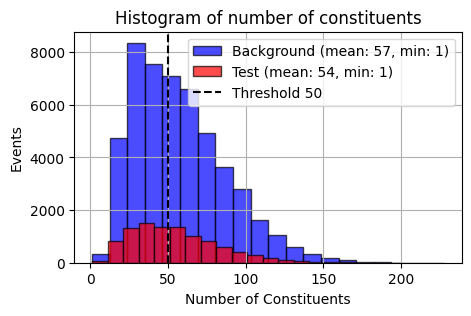

In [ ]:
#@title Analysis 1: number of costituents optimal
plt.figure(figsize=(5, 3))
plt.title("Histogram of number of constituents")
plt.xlabel("Number of Constituents")
plt.ylabel("Events")
plt.hist(np_numberofparticles, bins=20, color='blue', alpha=0.7, edgecolor='black', label=f"Background (mean: {int(np_numberofparticles.mean())}, min: {min(np_numberofparticles)})")
plt.hist(np_numberofparticles_test, bins=20, color='red', alpha=0.7, edgecolor='black', label=f"Test (mean: {int(np_numberofparticles_test.mean())}, min: {min(np_numberofparticles_test)})")
plt.axvline(x=max_constituents, color='black', linestyle='--', label=f"Threshold {max_constituents}")
plt.legend(), plt.grid(),
plt.show()

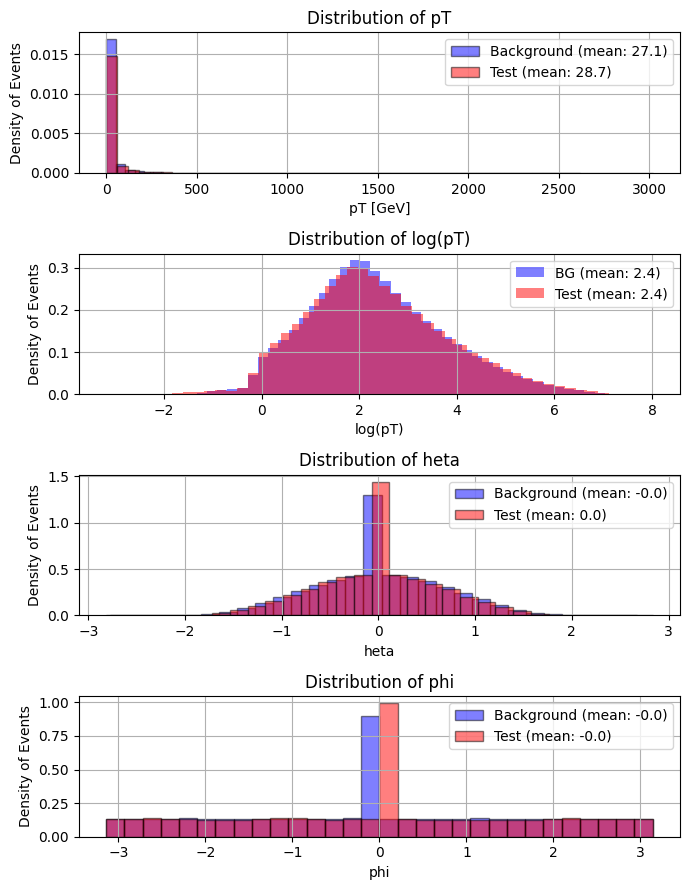

In [ ]:
#@title Analysis 2: distribution of pT, heta, phi before centering
plt.figure(figsize=(7, 9))
plt.subplot(4, 1, 1)
plt.title("Distribution of pT")
plt.xlabel("pT [GeV]")
plt.ylabel("Density of Events")
# .ravel() is like flatten
plt.hist(np_j1[:, :, 0].ravel(), bins=50, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {np_j1[:, :, 0].mean():.1f})", density=True)
plt.hist(np_j1_test[:, :, 0].ravel(), bins=50, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {np_j1_test[:, :, 0].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(4, 1, 2)
plt.title("Distribution of log(pT)")
plt.xlabel("log(pT)")
plt.ylabel("Density of Events")
# Filter pT> 0 and compute the log
log_bg = np.log(np_j1[:,:,0][np_j1[:,:,0] > 0])
# log_bg= np.log1p(np_j1[:,:,0].ravel())
log_test = np.log(np_j1_test[:,:,0][np_j1_test[:,:,0] > 0])
# log_test= np.log1p(np_j1_test[:,:,0].ravel())
plt.hist(log_bg, bins=50, color='blue', alpha=0.5, label=f"BG (mean: {log_bg.mean():.1f})", density=True)
plt.hist(log_test, bins=50, color='red', alpha=0.5, label=f"Test (mean: {log_test.mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(4, 1, 3)
plt.title("Distribution of heta")
plt.xlabel("heta")
plt.ylabel("Density of Events")
plt.hist(np_j1[:, :,1].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {np_j1[:, :,1].mean():.1f})", density=True)
plt.hist(np_j1_test[:, :,1].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {np_j1_test[:, :,1].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(4, 1, 4)
plt.title("Distribution of phi")
plt.xlabel("phi")
plt.ylabel("Density of Events")
plt.hist(np_j1[:, :, 2].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {np_j1[:, :, 2].mean():.1f})", density=True)
plt.hist(np_j1_test[:, :, 2].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {np_j1_test[:, :, 2].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.tight_layout()
plt.show()

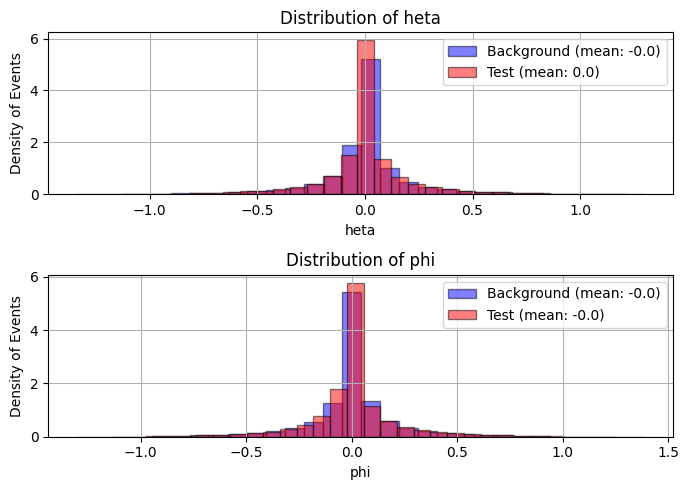

In [ ]:
#@title Analysis 3: distribution of eta, phi after centering
plt.figure(figsize=(7, 5))
plt.subplot(2, 1, 1)
plt.title("Distribution of heta")
plt.xlabel("heta")
plt.ylabel("Density of Events")
plt.hist(j1_background[:, :,1].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background[:, :,1].mean():.1f})", density=True)
plt.hist(j1_test[:, :,1].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test[:, :,1].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(2, 1, 2)
plt.title("Distribution of phi")
plt.xlabel("phi")
plt.ylabel("Density of Events")
plt.hist(j1_background[:, :, 2].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background[:, :, 2].mean():.1f})", density=True)
plt.hist(j1_test[:, :, 2].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test[:, :, 2].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.tight_layout()
plt.show()

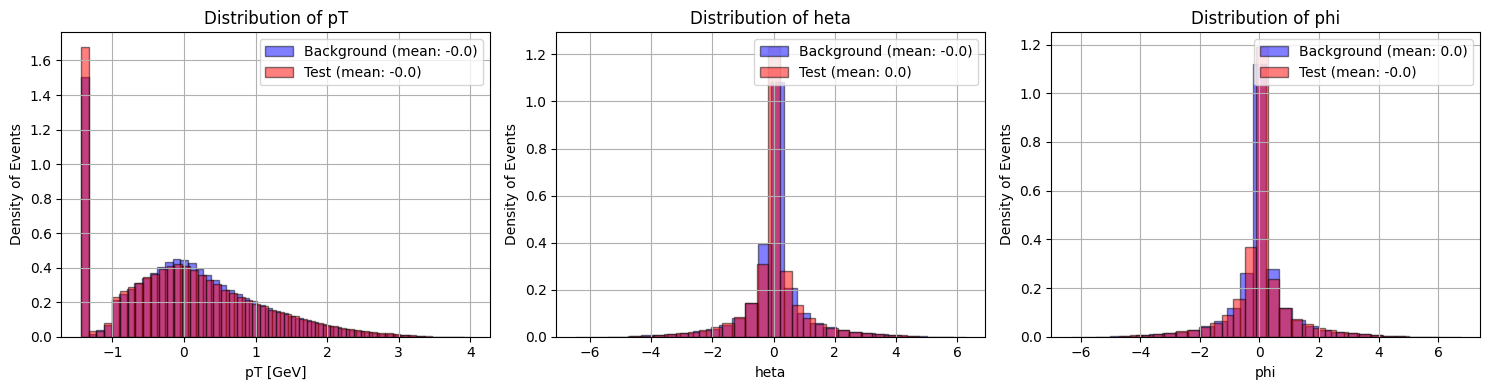

In [ ]:
#@title Analysis 4: distribution of pT, heta, phi after centering and scaling
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.title("Distribution of pT")
plt.xlabel("pT [GeV]")
plt.ylabel("Density of Events")
# .ravel() is like flatten
plt.hist(j1_background_scaled[:, :, 0].ravel(), bins=50, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background_scaled[:, :, 0].mean():.1f})", density=True)
plt.hist(j1_test_scaled[:, :, 0].ravel(), bins=50, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test_scaled[:, :, 0].mean():.1f})", density=True)

plt.legend(), plt.grid()

plt.subplot(1, 3, 2)
plt.title("Distribution of heta")
plt.xlabel("heta")
plt.ylabel("Density of Events")
plt.hist(j1_background_scaled[:, :,1].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background_scaled[:, :,1].mean():.1f})", density=True)
plt.hist(j1_test_scaled[:, :,1].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test_scaled[:, :,1].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(1, 3, 3)
plt.title("Distribution of phi")
plt.xlabel("phi")
plt.ylabel("Density of Events")
plt.hist(j1_background_scaled[:, :, 2].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background_scaled[:, :, 2].mean():.1f})", density=True)
plt.hist(j1_test_scaled[:, :, 2].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test_scaled[:, :, 2].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.tight_layout()
plt.show()


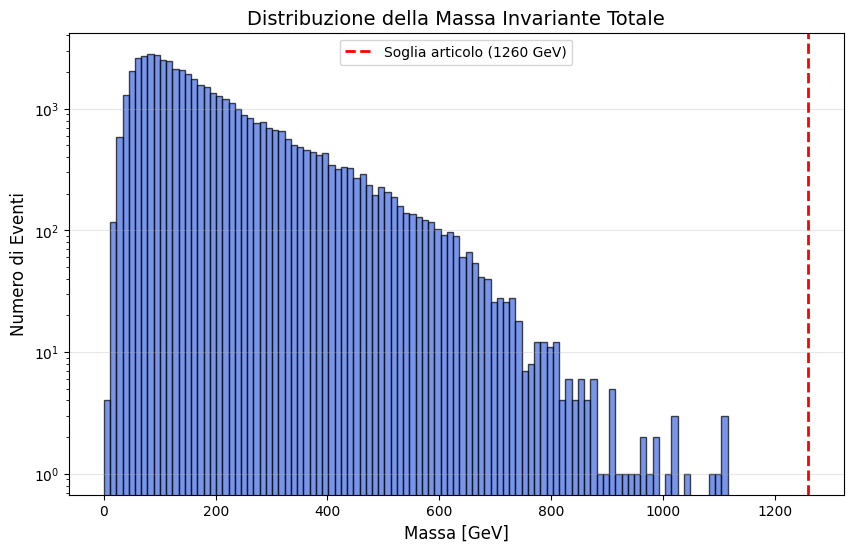

Statistiche della massa:
- Minima: 0.00 GeV
- Massima: 1115.50 GeV
- Media: 191.99 GeV


In [ ]:
def check_initial_mass(X_data):
    masses = []
    for i in range(len(X_data)):
        # Reshape dell'evento in particelle [pt, eta, phi]
        event = X_data[i].reshape(-1, 3)

        # Filtriamo le particelle "nulle" (padding)
        mask = event[:, 0] > 0
        p_reali = event[mask]

        if len(p_reali) == 0:
            continue

        # Calcolo componenti del quadri-momento usando la funzione sopra
        px, py, pz, e = cinematic(p_reali)

        # Somma dei quadri-momenti di tutte le particelle nell'evento
        E_tot = np.sum(e)
        Px_tot = np.sum(px)
        Py_tot = np.sum(py)
        Pz_tot = np.sum(pz)

        # Massa invariante: M^2 = E^2 - |P|^2
        m2 = E_tot**2 - (Px_tot**2 + Py_tot**2 + Pz_tot**2)

        # max(0, m2) evita problemi numerici con numeri piccolissimi negativi
        masses.append(np.sqrt(max(0, m2)))

    return np.array(masses)

# Esecuzione (Assicurati che j1_background sia definito)
m_iniziali = check_initial_mass(np_j1)

# Visualizzazione
plt.figure(figsize=(10, 6))
plt.hist(m_iniziali, bins=100, color='royalblue', alpha=0.7, edgecolor='black')
plt.axvline(1260, color='red', linestyle='--', linewidth=2, label='Soglia articolo (1260 GeV)')

plt.title("Distribuzione della Massa Invariante Totale", fontsize=14)
plt.xlabel("Massa [GeV]", fontsize=12)
plt.ylabel("Numero di Eventi", fontsize=12)
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

if len(m_iniziali) > 0:
    print(f"Statistiche della massa:")
    print(f"- Minima: {m_iniziali.min():.2f} GeV")
    print(f"- Massima: {m_iniziali.max():.2f} GeV")
    print(f"- Media: {m_iniziali.mean():.2f} GeV")

## Creation of torch-tensor and DataLoaders:

In [ ]:
#@title Torch DataLoader
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Split 70% Train - 30% Validation
X_train, X_val = train_test_split(j1_background_scaled, test_size=0.30, random_state=42)

# Conversion in PyTorch
tensor_X_train = torch.tensor(X_train, dtype=torch.float32)
tensor_X_val = torch.tensor(X_val, dtype=torch.float32)

# TensorDataset (Input, Target) -> Autoencoder input is (X, X)
train_dataset = TensorDataset(tensor_X_train, tensor_X_train)
val_dataset = TensorDataset(tensor_X_val, tensor_X_val)

# Creation of DataLoader
batch_size = 256 #@param {"type": "integer"}
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Test dataset
tensor_X_test = torch.tensor(j1_test_scaled, dtype=torch.float32)
test_dataset = TensorDataset(tensor_X_test, tensor_X_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of Batches for Train Loader:{len(train_loader)}")
print(f"Number of Batches for Val Loader: {len(val_loader)}")
print(f"Number of Batches for Test Loader (BlackBox): {len(test_loader)}")

Number of Batches for Train Loader:137
Number of Batches for Val Loader: 59
Number of Batches for Test Loader (BlackBox): 40


In [ ]:
#@title Prove of one element of the loaders
elem, elem = next(iter(train_loader))
print(elem.shape, end=" ")
elem, elem = next(iter(test_loader))
print(elem.shape, end=" ")
elem, elem = next(iter(val_loader))
print(elem.shape)

torch.Size([256, 50, 3]) torch.Size([256, 50, 3]) torch.Size([256, 50, 3])


# 2) Autoencoder:
tutto l'autoencoder è ok, per favore non modificarlo, al più modificare i parametri che compaiono, oppure modificare la loss

Latent dimension should be 4, 8 or 16

In [ ]:
import torch
import torch.nn as nn
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device is: ", device) #ciaoooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooo <3

Device is:  cuda


In [ ]:
#@title Modello con parametri aumentati (fix factor dinamico)
import torch
import torch.nn as nn
from torchsummary import summary

class Encoder(nn.Module):

    def __init__(
        self,
        hidden_dim=12,
        num_features=3,
        latent_dim=8,
        kernel1d=5,
        padd1d=2,
        max_constituents=max_constituents
    ):
        super(Encoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.max_constituents = max_constituents

        self.conv2d = nn.Conv2d(
            in_channels=1,
            out_channels=hidden_dim,
            kernel_size=(1, num_features)
        )
        self.input_activation = nn.LeakyReLU(0.2)

        self.encoder_cnn = nn.Sequential(
            # MIGLIORAMENTO 1: Conv1d kernel=1
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1),
            nn.GroupNorm(1, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Conv1d(hidden_dim, hidden_dim * 2, kernel_size=kernel1d, padding=padd1d),
            nn.GroupNorm(1, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.MaxPool1d(kernel_size=2, ceil_mode=True),

            nn.Conv1d(hidden_dim * 2, hidden_dim * 3, kernel_size=kernel1d, padding=padd1d),
            nn.GroupNorm(1, hidden_dim * 3),
            nn.LeakyReLU(0.2),
            nn.MaxPool1d(kernel_size=2, ceil_mode=True),
        )

        # FIX: calcolo factor dinamicamente invece di hardcodare 13
        # così funziona con qualsiasi kernel1d/padd1d
        import math
        after_pool1 = math.ceil(max_constituents / 2)
        after_pool2 = math.ceil(after_pool1 / 2)
        self.factor = after_pool2

        self.encoder_linear = nn.Sequential(
            nn.Linear(hidden_dim * 3 * self.factor, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv2d(x)
        x = self.input_activation(x)
        x = x.squeeze(-1)
        x = self.encoder_cnn(x)
        x = x.flatten(1)
        x = self.encoder_linear(x)
        return x

# Visualizzazione riassunto Encoder
# print("--- SUMMARY ENCODER ---")
# encoder_test = Encoder().to(device)
# if torch.cuda.is_available():
#   summary(encoder_test.cuda(), input_size=(max_constituents, 3))
# else:
#   summary(encoder_test, input_size=(max_constituents, 3))

In [ ]:
class Decoder(nn.Module):

    def __init__(
        self,
        hidden_dim=12,
        num_features=3,
        latent_dim=8,
        kernel1d=5,
        padd1d=2,
        max_constituents=max_constituents
    ):
        super(Decoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_features = num_features
        self.max_constituents = max_constituents

        # FIX: stesso calcolo dinamico del factor
        import math
        after_pool1 = math.ceil(max_constituents / 2)
        after_pool2 = math.ceil(after_pool1 / 2)
        self.factor = after_pool2

        self.decoder_linear = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim * 2, hidden_dim * 3 * self.factor),
            nn.LayerNorm(hidden_dim * 3 * self.factor),
            nn.LeakyReLU(0.2)
        )

        self.decoder_cnn = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ConvTranspose1d(hidden_dim * 3, hidden_dim * 2, kernel_size=kernel1d, padding=padd1d),
            nn.GroupNorm(1, hidden_dim * 2),
            nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),
            nn.ConvTranspose1d(hidden_dim * 2, hidden_dim, kernel_size=kernel1d, padding=padd1d),
            nn.GroupNorm(1, hidden_dim),
            nn.LeakyReLU(0.2)
        )

        self.conv2d_transpose = nn.ConvTranspose2d(
            hidden_dim, 1, kernel_size=(1, num_features)
        )

    def forward(self, x):
        x = self.decoder_linear(x)
        x = x.view(-1, self.hidden_dim * 3, self.factor)
        x = self.decoder_cnn(x)
        x = x.unsqueeze(-1)
        x = self.conv2d_transpose(x)
        x = x.squeeze(1)
        x = x[:, :self.max_constituents, :]
        return x


# print("--- SUMMARY DECODER ex---")
# decoder_test = Decoder(latent_dim=8, max_constituents=50).to(device)
# if torch.cuda.is_available():
#     summary(decoder_test.cuda(), input_size=(8,))
# else:
#     summary(decoder_test, input_size=(8,))

In [ ]:
class DeepConvAutoencoder(nn.Module):

    def __init__(
        self,
        num_features=3,
        latent_dim=8,
        hidden_dim=64,
        kernel1d=7,
        padd1d=2,
        max_constituents=max_constituents
    ):
        super(DeepConvAutoencoder, self).__init__()
        self.encoder = Encoder(hidden_dim, num_features, latent_dim, kernel1d, padd1d, max_constituents)
        self.decoder = Decoder(hidden_dim, num_features, latent_dim, kernel1d, padd1d, max_constituents)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def get_latent(self, x):
        return self.encoder(x)


# Istanziazione con parametri aumentati
lat_dim = 8  # NON si tocca

model = DeepConvAutoencoder(
    num_features=3,
    latent_dim=lat_dim,
    hidden_dim=128,   # era 64
    kernel1d=7,       # era 5
    padd1d=3,         # kernel1d // 2
    max_constituents=max_constituents
).to(device)

print(f"factor calcolato: {model.encoder.factor}")  # deve stampare 13
print(f"Parametri totali: {sum(p.numel() for p in model.parameters()):,}")

if torch.cuda.is_available():
    summary(model.cuda(), (max_constituents, 3))
else:
    summary(model, input_size=(max_constituents, 3))
#print(f\"Model Multi-layer CNN created on: {device}\")

factor calcolato: 13
Parametri totali: 4,496,521
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 128, 50, 1]             512
         LeakyReLU-2           [-1, 128, 50, 1]               0
            Conv1d-3              [-1, 128, 50]          16,512
         GroupNorm-4              [-1, 128, 50]             256
         LeakyReLU-5              [-1, 128, 50]               0
            Conv1d-6              [-1, 256, 50]         229,632
         GroupNorm-7              [-1, 256, 50]             512
         LeakyReLU-8              [-1, 256, 50]               0
         MaxPool1d-9              [-1, 256, 25]               0
           Conv1d-10              [-1, 384, 25]         688,512
        GroupNorm-11              [-1, 384, 25]             768
        LeakyReLU-12              [-1, 384, 25]               0
        MaxPool1d-13              [-1, 384, 13]       

## Training
*   Messo il salvataggio in automatico


In [ ]:
#@title train
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR # Scheduler
import matplotlib.pyplot as plt

load_saved_model = False #@param {type:"boolean"}
best_model_path = '/content/drive/MyDrive/set dati machine learning/best_autoencoder.pth'

# Loss Definition, Optimizer and Scheduler
criterion = nn.MSELoss()
# Starts: LR (0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Scheduler: for each step_size (10 epochs), LR = LR * gamma
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)

if load_saved_model:
    model.load_state_dict(torch.load(best_model_path))
    print(f"MODEL LOADED: {best_model_path}")
else:
    print("NEW TRAINING STARTED")


    epochs = 0 #@param {"type": "integer"}
    train_losses = []
    val_losses = []

    print("\nStart training with Autoencoder...\n")


    # Varible useful to save the best model if best_val_loss decreses
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train() #training mode
        running_train_loss = 0.0

        for batch_x, _ in train_loader:
            batch_x = batch_x.to(device)

            # Forward pass
            reconstructed = model(batch_x)

            # (Loss)
            loss = criterion(reconstructed, batch_x)

            # Backward pass e optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * batch_x.size(0)

        # Compute loss mean loss of the epoch
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # --- FASE VALIDATION ---
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for batch_x, _ in val_loader:
                batch_x = batch_x.to(device)
                reconstructed = model(batch_x)
                loss = criterion(reconstructed, batch_x)
                running_val_loss += loss.item() * batch_x.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        # --- SALVATAGGIO MIGLIOR MODELLO ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_path = '/content/drive/MyDrive/set dati machine learning/best_autoencoder.pth'
            torch.save(model.state_dict(), best_model_path)
            # Il print appare solo quando viene trovato un miglioramento
            print(f"--> better model found! Model saved at: {epoch_val_loss:.4f}")
            print(f"--> Weights saved in: {best_model_path}")
        # step of scheduler
        scheduler.step()

        # Print every 3 epochs
        current_lr = scheduler.get_last_lr()[0]
        if (epoch) % 3 == 0:
            print(f"Epoch [{epoch+1:2d}/{epochs}] | LR: {current_lr:.5f} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")



NEW TRAINING STARTED

Start training with Autoencoder...



In [ ]:
#@title MODIFICA 3: Denoising Autoencoder + Early Stopping
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt

def weighted_masked_loss(recon, target):
    mask = (target.abs().sum(dim=-1) > 0).float()
    weights = torch.tensor([1.0, 3.0, 3.0], device=target.device)
    loss_per_comp = ((recon - target) ** 2) * weights
    loss_per_particle = loss_per_comp.sum(dim=-1)
    loss_masked = (loss_per_particle * mask).sum() / (mask.sum() + 1e-8)
    return loss_masked

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

epochs = 100         #@param {"type": "integer"}
noise_factor = 0.05 #@param {"type": "number"}
patience_limit = 15 #@param {"type": "integer"}

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_path = '/content/drive/MyDrive/set dati machine learning/best_autoencoder.pth'

print("\nStart Denoising AE training...\n")

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    running_train_loss = 0.0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)

        # MODIFICA 3: aggiungi rumore SOLO all'input, target rimane pulito
        # la maschera evita di aggiungere rumore sulle particelle di padding
        mask_3d = (batch_x.abs().sum(dim=-1, keepdim=True) > 0).float()
        batch_x_noisy = batch_x + noise_factor * torch.randn_like(batch_x)
        batch_x_noisy = batch_x_noisy * mask_3d

        reconstructed = model(batch_x_noisy)           # input: rumoroso
        loss = weighted_masked_loss(reconstructed, batch_x)  # target: pulito

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * batch_x.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- VALIDATION (senza rumore) ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_x, _ in val_loader:
            batch_x = batch_x.to(device)
            reconstructed = model(batch_x)
            loss = weighted_masked_loss(reconstructed, batch_x)
            running_val_loss += loss.item() * batch_x.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # --- EARLY STOPPING + SAVE ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience_limit:
            print(f"Early stopping all'epoca {epoch+1} (val_loss ferma da {patience_limit} epoche)")
            break

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch [{epoch+1:2d}/{epochs}] "
        f"| LR: {current_lr:.5f} "
        f"| Train Loss: {epoch_train_loss:.4f} "
        f"| Val Loss: {epoch_val_loss:.4f} "
        f"| Patience: {patience_counter}/{patience_limit}"
    )


Start Denoising AE training...

Epoch [ 1/100] | LR: 0.00100 | Train Loss: 11.3656 | Val Loss: 6.2770 | Patience: 0/15
Epoch [ 2/100] | LR: 0.00100 | Train Loss: 6.2963 | Val Loss: 6.2717 | Patience: 0/15
Epoch [ 3/100] | LR: 0.00100 | Train Loss: 6.2897 | Val Loss: 6.2617 | Patience: 0/15
Epoch [ 4/100] | LR: 0.00100 | Train Loss: 6.0335 | Val Loss: 5.7945 | Patience: 0/15
Epoch [ 5/100] | LR: 0.00100 | Train Loss: 5.7689 | Val Loss: 5.6483 | Patience: 0/15
Epoch [ 6/100] | LR: 0.00100 | Train Loss: 5.6253 | Val Loss: 5.5562 | Patience: 0/15
Epoch [ 7/100] | LR: 0.00100 | Train Loss: 5.3912 | Val Loss: 5.1252 | Patience: 0/15
Epoch [ 8/100] | LR: 0.00100 | Train Loss: 5.0040 | Val Loss: 4.8002 | Patience: 0/15
Epoch [ 9/100] | LR: 0.00100 | Train Loss: 4.7577 | Val Loss: 4.6686 | Patience: 0/15
Epoch [10/100] | LR: 0.00100 | Train Loss: 4.6964 | Val Loss: 4.7669 | Patience: 1/15
Epoch [11/100] | LR: 0.00100 | Train Loss: 4.6421 | Val Loss: 4.5820 | Patience: 0/15
Epoch [12/100] | LR:

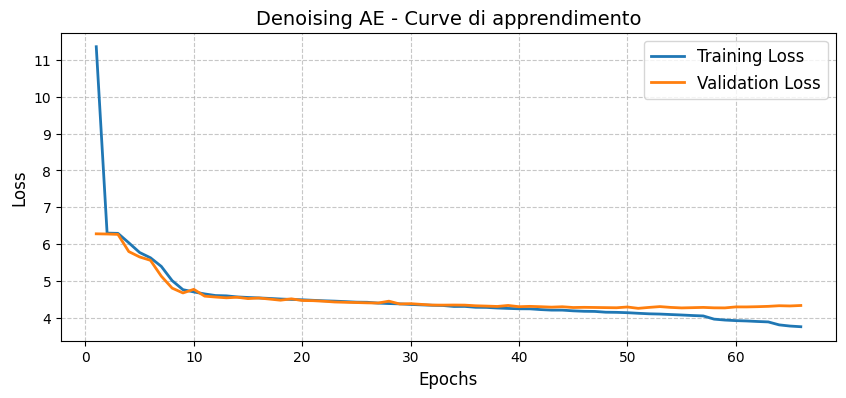

In [ ]:
#@title plot loss

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Training Loss', linewidth=2)
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Denoising AE - Curve di apprendimento', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Analisi spazio latente:

prima rappresentazioni componenti spazio latente e ricostruzione, la ricostruzione non è un granche perche non è il nostro obbiettivo vogliamo anomaly detection. piu ricostrisco bene meno sono bravoa fare anomaly detection, per questo prima validazione cosi bassa

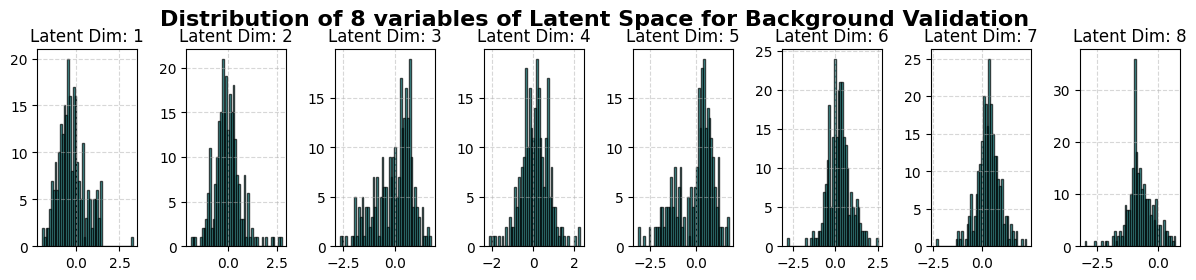

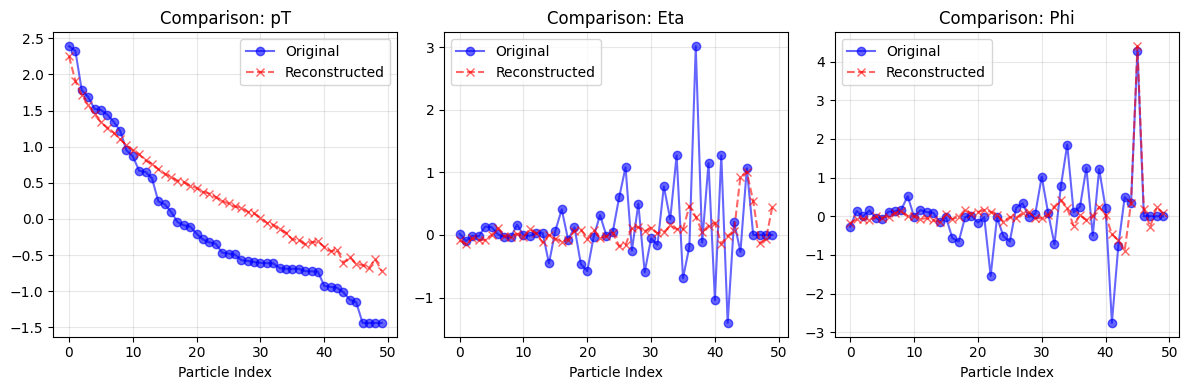

In [ ]:
#@title Analysis Latent Space
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()
#Use of a batch to do plots
sample_data, _ = next(iter(val_loader))
sample_data = sample_data.to(device)

with torch.no_grad():
    latent_space = model.get_latent(sample_data)
    reconstructed_data = model(sample_data)

# On cpu
sample_data_np = sample_data.cpu().numpy()
latent_space_np = latent_space.cpu().numpy()
reconstructed_data_np = reconstructed_data.cpu().numpy()


# ==========================================
# PLOT 1: LATENT SPACE
# ==========================================
plt.figure(figsize=(12, 5))
plt.suptitle("Distribution of 8 variables of Latent Space for Background Validation", fontsize=16, fontweight='bold')

for i in range(lat_dim):
    plt.subplot(2, 8, i+1)
    plt.hist(latent_space_np[:, i], bins=50, color='teal', alpha=0.7, edgecolor='black')
    plt.title(f"Latent Dim: {i+1}")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# ==========================================
# PLOT 2: ORIGINAL vs RECONSTRUCTED
# ==========================================
# Taking the first events of the loader
evento_idx = 1
# (BATCHSIZE, MAX_CONSTITUENTS, 3)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels = ['pT', 'Eta', 'Phi']

for i in range(3):
    # Plotting each kinematic variable separately
    axes[i].plot(sample_data_np[evento_idx, :, i], label='Original', color='blue', marker='o', alpha=0.6)
    axes[i].plot(reconstructed_data_np[evento_idx, :, i], label='Reconstructed', color='red', marker='x', linestyle='--', alpha=0.6)
    axes[i].set_title(f"Comparison: {labels[i]}")
    axes[i].set_xlabel("Particle Index")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#print(latent space)

# 2.1) metodi di clusterizzazione classica etc etc altre prove

In [ ]:
import torch
import numpy as np
import os

print("Inizio estrazione dello Spazio Latente (8D)...")

# Assicuriamoci che il modello sia in modalità valutazione
model.eval()

def extract_latent_space(dataloader):
    latent_vectors = []
    with torch.no_grad():
        for batch_x, _ in dataloader:
            batch_x = batch_x.to(device)
            # Usiamo SOLO l'encoder!
            latent = model.get_latent(batch_x)
            latent_vectors.append(latent.cpu().numpy())

    # Uniamo tutti i batch in un unico grande array numpy
    return np.vstack(latent_vectors)

# Per l'Anomaly Detection, abbiamo bisogno del background intero (train + val)
# Creiamo un DataLoader unico senza shuffle per estrarlo tutto in ordine
X_bg_full_tensor = torch.tensor(j1_background_scaled, dtype=torch.float32)
bg_full_loader = DataLoader(TensorDataset(X_bg_full_tensor, X_bg_full_tensor),
                            batch_size=256,
                            shuffle=False)

# Estraiamo!
latent_bg = extract_latent_space(bg_full_loader)
latent_test = extract_latent_space(test_loader)

print(f"Dimensions Background Latent: {latent_bg.shape}")
print(f"Dimensions BlackBox Latent: {latent_test.shape}")

# Salviamo questi nuovi dataset leggeri, saranno il punto di partenza per il Quantum Kernel!
save_dir = '/content/drive/MyDrive/set dati machine learning/processed_data'
np.save(os.path.join(save_dir, 'latent_bg.npy'), latent_bg)
np.save(os.path.join(save_dir, 'latent_blackbox.npy'), latent_test)

print("Dataset latenti salvati con successo su Drive!")

Inizio estrazione dello Spazio Latente (8D)...
Dimensions Background Latent: (50000, 8)
Dimensions BlackBox Latent: (10000, 8)
Dataset latenti salvati con successo su Drive!


Calcolo dell'Errore di Ricostruzione (MSE) come Anomaly Score...

---> PRESTAZIONE CON ERRORE DI RICOSTRUZIONE (AUC): 0.6437


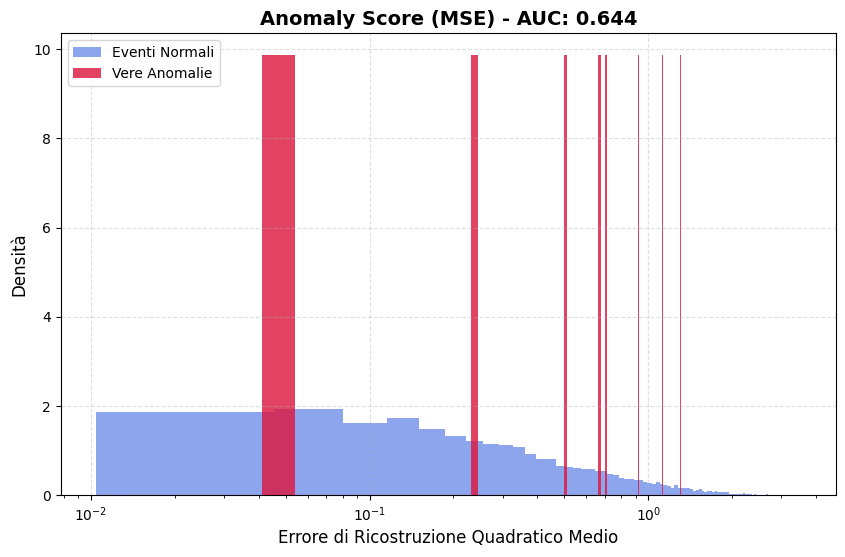

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os
print("Calcolo dell'Errore di Ricostruzione (MSE) come Anomaly Score...")

model.eval()
reconstruction_scores = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        reconstructed = model(batch_x)

        # Correct calculation: MSE per event
        # (batch, 50, 3) -> Mean over dimensions 1 and 2 to get (batch,)
        mse_per_event = torch.mean((batch_x - reconstructed)**2, dim=(1, 2))

        # Save results correctly
        reconstruction_scores.extend(mse_per_event.cpu().numpy())

reconstruction_scores = np.array(reconstruction_scores)

# --- The rest of your code remains the same ---
save_dir = '/content/drive/MyDrive/set dati machine learning/processed_data'
masterkey_path = os.path.join(save_dir, "events_LHCO2020_BlackBox1.masterkey")
true_labels_full = np.loadtxt(masterkey_path)
true_labels = true_labels_full[:len(reconstruction_scores)]

fpr, tpr, thresholds = roc_curve(true_labels, reconstruction_scores)
roc_auc = auc(fpr, tpr)

print(f"\n---> PRESTAZIONE CON ERRORE DI RICOSTRUZIONE (AUC): {roc_auc:.4f}")

# Histogram visualization
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_scores[true_labels == 0], bins=100, color='royalblue', alpha=0.6, density=True, label='Eventi Normali')
plt.hist(reconstruction_scores[true_labels == 1], bins=100, color='crimson', alpha=0.8, density=True, label='Vere Anomalie')
plt.title(f"Anomaly Score (MSE) - AUC: {roc_auc:.3f}", fontsize=14, fontweight='bold')
plt.xlabel("Errore di Ricostruzione Quadratico Medio", fontsize=12)
plt.ylabel("Densità", fontsize=12)
plt.xscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


Caricamento dati latenti e label...

Ciclo K-Means per k = 2 ... 20

  k= 2 | AUC = 0.5635 | Inertia = 293718.3
  k= 3 | AUC = 0.5704 | Inertia = 263377.6
  k= 4 | AUC = 0.5829 | Inertia = 240408.9
  k= 5 | AUC = 0.6269 | Inertia = 221884.5
  k= 6 | AUC = 0.5864 | Inertia = 206987.1
  k= 7 | AUC = 0.6180 | Inertia = 197731.0
  k= 8 | AUC = 0.6050 | Inertia = 189493.4
  k= 9 | AUC = 0.6166 | Inertia = 184162.3
  k=10 | AUC = 0.6599 | Inertia = 177130.0
  k=11 | AUC = 0.6457 | Inertia = 172265.8
  k=12 | AUC = 0.6629 | Inertia = 169352.9
  k=13 | AUC = 0.6763 | Inertia = 167255.7
  k=14 | AUC = 0.6524 | Inertia = 162968.0
  k=15 | AUC = 0.6679 | Inertia = 159146.5
  k=16 | AUC = 0.6533 | Inertia = 156575.7
  k=17 | AUC = 0.6389 | Inertia = 153952.5
  k=18 | AUC = 0.6413 | Inertia = 152388.7
  k=19 | AUC = 0.6343 | Inertia = 150273.0
  k=20 | AUC = 0.6062 | Inertia = 147876.1

---> MIGLIOR K: 13 con AUC = 0.6763


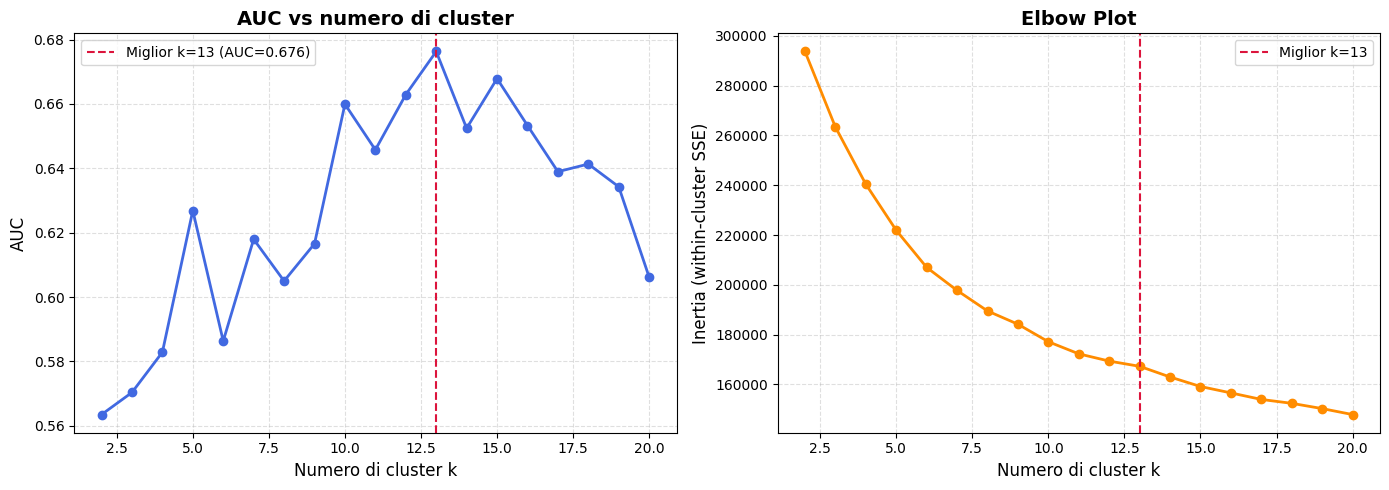

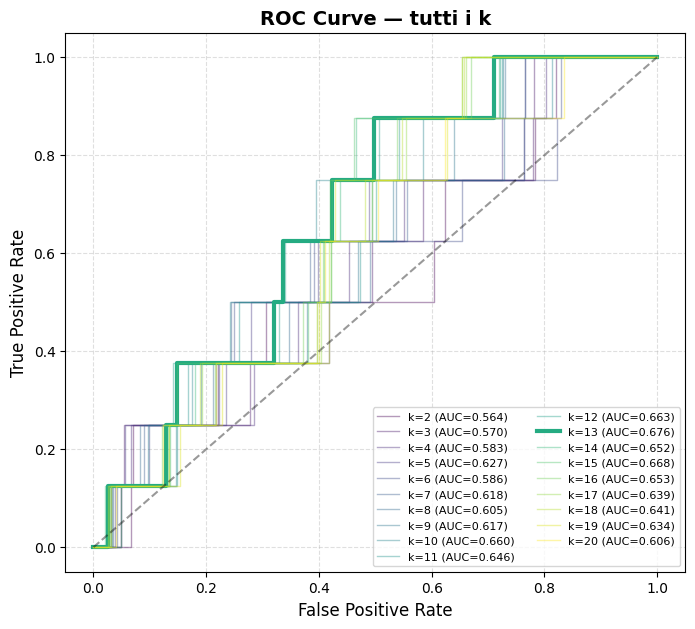


Dettaglio per il miglior k=13...


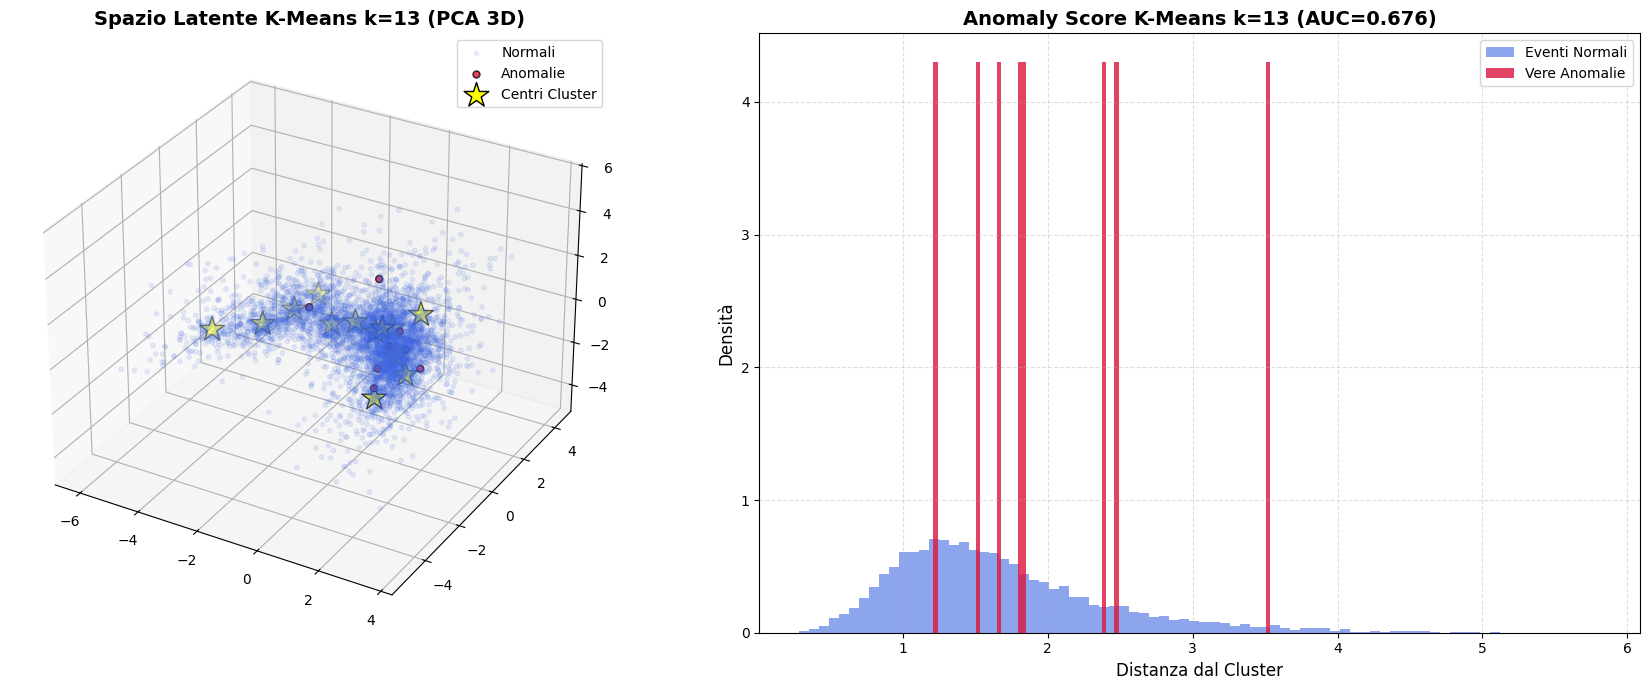

In [ ]:
#@title K-Means: ricerca migliore numero di cluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import os

# ==========================================
# 1. CARICAMENTO DATI E LABEL (invariato)
# ==========================================
print("Caricamento dati latenti e label...")
save_dir = '/content/drive/MyDrive/set dati machine learning/processed_data'
latent_bg = np.load(os.path.join(save_dir, 'latent_bg.npy'))
latent_blackbox = np.load(os.path.join(save_dir, 'latent_blackbox.npy'))

masterkey_path = os.path.join(save_dir, "events_LHCO2020_BlackBox1.masterkey")
true_labels_full = np.loadtxt(masterkey_path)
true_labels = true_labels_full[:latent_blackbox.shape[0]]

# ==========================================
# 2. NORMALIZZAZIONE (invariata)
# ==========================================
scaler_l = StandardScaler()
latent_bg_norm = scaler_l.fit_transform(latent_bg)
latent_blackbox_norm = scaler_l.transform(latent_blackbox)

# ==========================================
# 3. CICLO SU K
# ==========================================
k_values = list(range(2, 21))  # prova k=2,3,...,20 — modifica a piacere

results = []  # lista di dict con tutti i risultati per ogni k

print(f"\nCiclo K-Means per k = {k_values[0]} ... {k_values[-1]}\n")

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(latent_bg_norm)

    distances = kmeans.transform(latent_blackbox_norm)
    scores = np.min(distances, axis=1)

    fpr, tpr, _ = roc_curve(true_labels, scores)
    roc_auc = auc(fpr, tpr)

    if roc_auc < 0.5:
        roc_auc = 1 - roc_auc
        scores = -scores
        fpr, tpr, _ = roc_curve(true_labels, scores)

    results.append({
        'k': k,
        'kmeans': kmeans,
        'scores': scores,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'inertia': kmeans.inertia_
    })

    print(f"  k={k:2d} | AUC = {roc_auc:.4f} | Inertia = {kmeans.inertia_:.1f}")

# Miglior k per AUC
best = max(results, key=lambda x: x['auc'])
print(f"\n---> MIGLIOR K: {best['k']} con AUC = {best['auc']:.4f}")

# ==========================================
# 4. PLOT 1: AUC e Inertia al variare di k
# ==========================================
ks    = [r['k']       for r in results]
aucs  = [r['auc']     for r in results]
inertias = [r['inertia'] for r in results]

fig, (ax_auc, ax_in) = plt.subplots(1, 2, figsize=(14, 5))

ax_auc.plot(ks, aucs, marker='o', linewidth=2, color='royalblue')
ax_auc.axvline(best['k'], color='crimson', linestyle='--', label=f"Miglior k={best['k']} (AUC={best['auc']:.3f})")
ax_auc.set_xlabel("Numero di cluster k", fontsize=12)
ax_auc.set_ylabel("AUC", fontsize=12)
ax_auc.set_title("AUC vs numero di cluster", fontsize=14, fontweight='bold')
ax_auc.legend()
ax_auc.grid(True, linestyle='--', alpha=0.4)

# Elbow plot (inertia) — utile per capire quanti cluster sono "naturali"
ax_in.plot(ks, inertias, marker='o', linewidth=2, color='darkorange')
ax_in.axvline(best['k'], color='crimson', linestyle='--', label=f"Miglior k={best['k']}")
ax_in.set_xlabel("Numero di cluster k", fontsize=12)
ax_in.set_ylabel("Inertia (within-cluster SSE)", fontsize=12)
ax_in.set_title("Elbow Plot", fontsize=14, fontweight='bold')
ax_in.legend()
ax_in.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ==========================================
# 5. PLOT 2: ROC curve di tutti i k sovrapposti
# ==========================================
plt.figure(figsize=(8, 7))
cmap = plt.cm.viridis(np.linspace(0, 1, len(results)))

for r, color in zip(results, cmap):
    lw = 3 if r['k'] == best['k'] else 1
    alpha = 1.0 if r['k'] == best['k'] else 0.4
    plt.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
             label=f"k={r['k']} (AUC={r['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — tutti i k", fontsize=14, fontweight='bold')
plt.legend(fontsize=8, loc='lower right', ncol=2)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# ==========================================
# 6. PLOT 3: dettaglio sul miglior k (i tuoi grafici originali)
# ==========================================
print(f"\nDettaglio per il miglior k={best['k']}...")

pca = PCA(n_components=3)
latent_3d = pca.fit_transform(latent_blackbox_norm)
cluster_centers_3d = pca.transform(best['kmeans'].cluster_centers_)

true_normal_3d   = latent_3d[true_labels == 0]
true_anomaly_3d  = latent_3d[true_labels == 1]
sample_size_norm = min(5000, len(true_normal_3d))

fig = plt.figure(figsize=(18, 7))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(true_normal_3d[:sample_size_norm, 0],
            true_normal_3d[:sample_size_norm, 1],
            true_normal_3d[:sample_size_norm, 2],
            c='royalblue', alpha=0.1, label='Normali', s=10)
ax1.scatter(true_anomaly_3d[:, 0],
            true_anomaly_3d[:, 1],
            true_anomaly_3d[:, 2],
            c='crimson', alpha=0.8, label='Anomalie', s=25, edgecolors='black')
ax1.scatter(cluster_centers_3d[:, 0],
            cluster_centers_3d[:, 1],
            cluster_centers_3d[:, 2],
            c='yellow', marker='*', s=350, edgecolors='black', label='Centri Cluster')
ax1.set_title(f"Spazio Latente K-Means k={best['k']} (PCA 3D)", fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')

ax2 = fig.add_subplot(122)
ax2.hist(best['scores'][true_labels == 0], bins=80, color='royalblue',
         alpha=0.6, density=True, label='Eventi Normali')
ax2.hist(best['scores'][true_labels == 1], bins=80, color='crimson',
         alpha=0.8, density=True, label='Vere Anomalie')
ax2.set_title(f"Anomaly Score K-Means k={best['k']} (AUC={best['auc']:.3f})",
              fontsize=14, fontweight='bold')
ax2.set_xlabel("Distanza dal Cluster", fontsize=12)
ax2.set_ylabel("Densità", fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Variabile kmeans aggiornata al miglior k (compatibile con il resto del notebook)
kmeans = best['kmeans']
anomaly_scores = best['scores']
k_clusters = best['k']
roc_auc = best['auc']


Preparazione dati per t-SNE...
Calcolo t-SNE su 5008 eventi (potrebbe richiedere un paio di minuti)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



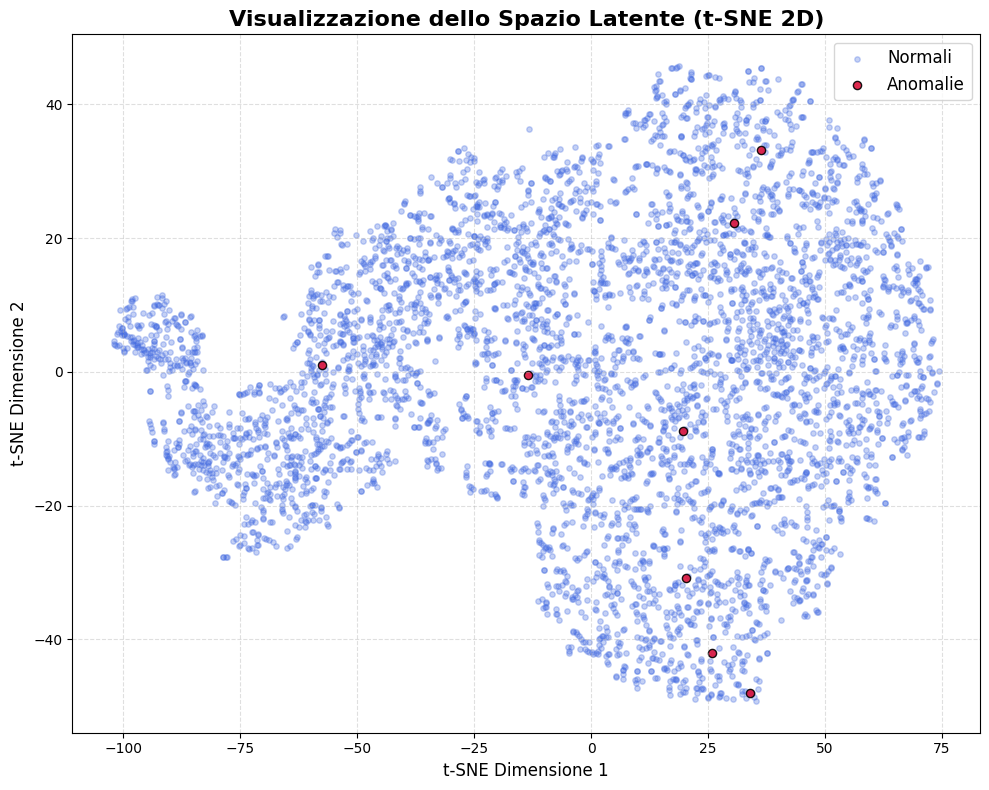

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 5. GRAFICI CON t-SNE (2D)
# ==========================================
print("\nPreparazione dati per t-SNE...")

# 1. Trovo gli indici di background (0) e anomalie (1)
idx_normal = np.where(true_labels == 0)[0]
idx_anomaly = np.where(true_labels == 1)[0]

# 2. Sottocampiono i normali a 5000 per non far esplodere i tempi del t-SNE
np.random.seed(42)
sample_size = min(5000, len(idx_normal))
idx_normal_sub = np.random.choice(idx_normal, sample_size, replace=False)

# 3. Unisco gli indici delle anomalie con quelli del background sottocampionato
idx_tsne = np.concatenate([idx_normal_sub, idx_anomaly])

# 4. Estraggo i dati e le label corrispondenti
latent_for_tsne = latent_blackbox_norm[idx_tsne]
labels_for_tsne = true_labels[idx_tsne]

print(f"Calcolo t-SNE su {len(latent_for_tsne)} eventi (potrebbe richiedere un paio di minuti)...")
# Inizializzo e calcolo il t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
latent_2d_tsne = tsne.fit_transform(latent_for_tsne)

# Separazione per il plot
tsne_normali = latent_2d_tsne[labels_for_tsne == 0]
tsne_anomalie = latent_2d_tsne[labels_for_tsne == 1]

# Creazione del Plot
fig = plt.figure(figsize=(10, 8))

# Disegno prima i normali (in blu)
plt.scatter(tsne_normali[:, 0], tsne_normali[:, 1],
            c='royalblue', alpha=0.3, label='Normali', s=15)

# Disegno sopra le anomalie (in rosso)
plt.scatter(tsne_anomalie[:, 0], tsne_anomalie[:, 1],
            c='crimson', alpha=0.9, label='Anomalie', s=35, edgecolors='black')

plt.title("Visualizzazione dello Spazio Latente (t-SNE 2D)", fontsize=16, fontweight='bold')
plt.xlabel("t-SNE Dimensione 1", fontsize=12)
plt.ylabel("t-SNE Dimensione 2", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Ciclo GMM per n_components = 2 ... 20

  n= 2 | AUC = 0.5709 | BIC = 979275.9
  n= 3 | AUC = 0.5767 | BIC = 940417.9
  n= 4 | AUC = 0.5970 | BIC = 924217.4
  n= 5 | AUC = 0.5918 | BIC = 916656.1
  n= 6 | AUC = 0.5905 | BIC = 905850.4
  n= 7 | AUC = 0.5923 | BIC = 898518.9
  n= 8 | AUC = 0.6016 | BIC = 895434.9
  n= 9 | AUC = 0.6007 | BIC = 893839.2
  n=10 | AUC = 0.6002 | BIC = 891107.2
  n=11 | AUC = 0.6192 | BIC = 892055.0
  n=12 | AUC = 0.5889 | BIC = 889652.7
  n=13 | AUC = 0.5944 | BIC = 886928.9
  n=14 | AUC = 0.6069 | BIC = 886754.3
  n=15 | AUC = 0.6097 | BIC = 885947.1
  n=16 | AUC = 0.5967 | BIC = 886208.9
  n=17 | AUC = 0.6004 | BIC = 885921.5
  n=18 | AUC = 0.6078 | BIC = 884822.4
  n=19 | AUC = 0.6228 | BIC = 883880.5
  n=20 | AUC = 0.6275 | BIC = 883184.7

---> MIGLIOR N: 20 con AUC = 0.6275


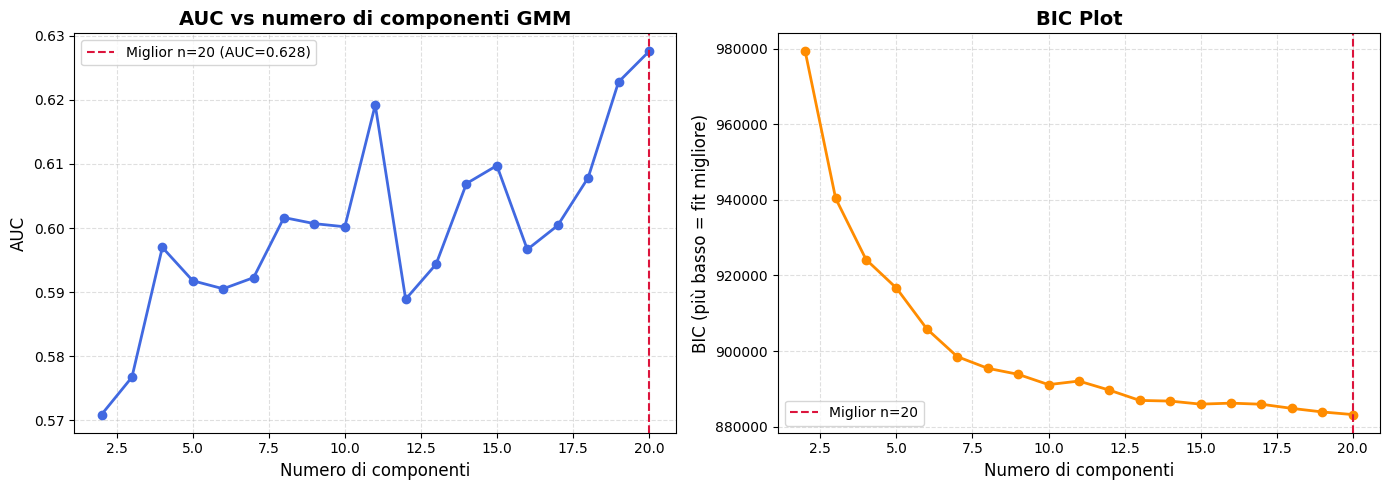

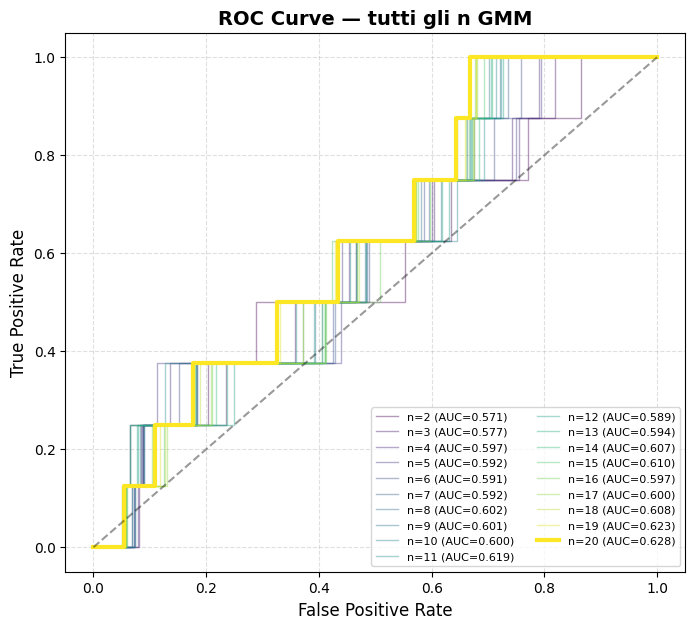

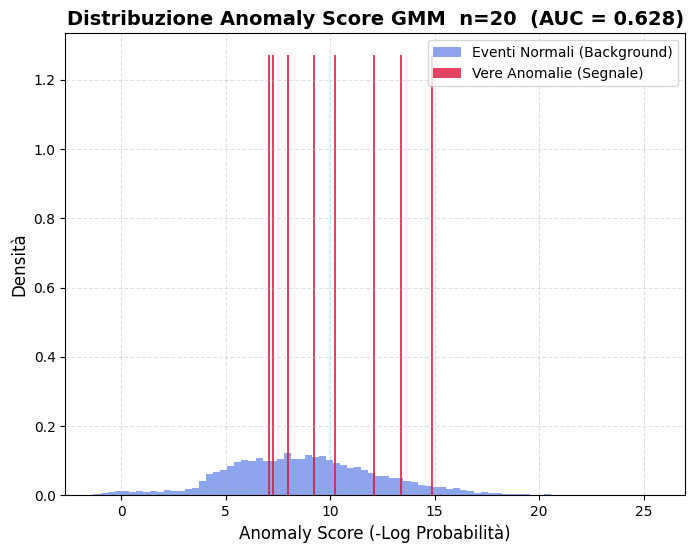

In [ ]:
#@title GMM: ricerca migliore numero di componenti
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CICLO SUL NUMERO DI COMPONENTI
# ==========================================
n_values = list(range(2, 21))  # prova n=2,3,...,20 — modifica a piacere

results_gmm = []

print(f"Ciclo GMM per n_components = {n_values[0]} ... {n_values[-1]}\n")

for n in n_values:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(latent_bg_norm)

    scores = -gmm.score_samples(latent_blackbox_norm)

    fpr, tpr, _ = roc_curve(true_labels, scores)
    roc_auc = auc(fpr, tpr)

    if roc_auc < 0.5:
        roc_auc = 1 - roc_auc
        scores = -scores
        fpr, tpr, _ = roc_curve(true_labels, scores)

    results_gmm.append({
        'n': n,
        'gmm': gmm,
        'scores': scores,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'bic': gmm.bic(latent_bg_norm)   # BIC: misura qualità fit (più basso = meglio)
    })

    print(f"  n={n:2d} | AUC = {roc_auc:.4f} | BIC = {gmm.bic(latent_bg_norm):.1f}")

best_gmm = max(results_gmm, key=lambda x: x['auc'])
print(f"\n---> MIGLIOR N: {best_gmm['n']} con AUC = {best_gmm['auc']:.4f}")

# ==========================================
# PLOT 1: AUC e BIC al variare di n
# ==========================================
ns   = [r['n']   for r in results_gmm]
aucs = [r['auc'] for r in results_gmm]
bics = [r['bic'] for r in results_gmm]

fig, (ax_auc, ax_bic) = plt.subplots(1, 2, figsize=(14, 5))

ax_auc.plot(ns, aucs, marker='o', linewidth=2, color='royalblue')
ax_auc.axvline(best_gmm['n'], color='crimson', linestyle='--',
               label=f"Miglior n={best_gmm['n']} (AUC={best_gmm['auc']:.3f})")
ax_auc.set_xlabel("Numero di componenti", fontsize=12)
ax_auc.set_ylabel("AUC", fontsize=12)
ax_auc.set_title("AUC vs numero di componenti GMM", fontsize=14, fontweight='bold')
ax_auc.legend()
ax_auc.grid(True, linestyle='--', alpha=0.4)

# BIC: analogo dell'elbow plot per il GMM
ax_bic.plot(ns, bics, marker='o', linewidth=2, color='darkorange')
ax_bic.axvline(best_gmm['n'], color='crimson', linestyle='--',
               label=f"Miglior n={best_gmm['n']}")
ax_bic.set_xlabel("Numero di componenti", fontsize=12)
ax_bic.set_ylabel("BIC (più basso = fit migliore)", fontsize=12)
ax_bic.set_title("BIC Plot", fontsize=14, fontweight='bold')
ax_bic.legend()
ax_bic.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: ROC curve di tutti gli n sovrapposti
# ==========================================
plt.figure(figsize=(8, 7))
cmap = plt.cm.viridis(np.linspace(0, 1, len(results_gmm)))

for r, color in zip(results_gmm, cmap):
    lw    = 3   if r['n'] == best_gmm['n'] else 1
    alpha = 1.0 if r['n'] == best_gmm['n'] else 0.4
    plt.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
             label=f"n={r['n']} (AUC={r['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — tutti gli n GMM", fontsize=14, fontweight='bold')
plt.legend(fontsize=8, loc='lower right', ncol=2)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# ==========================================
# PLOT 3: distribuzione score del miglior n (identico all'originale)
# ==========================================
plt.figure(figsize=(8, 6))
plt.hist(best_gmm['scores'][true_labels == 0], bins=80, color='royalblue',
         alpha=0.6, density=True, label='Eventi Normali (Background)')
plt.hist(best_gmm['scores'][true_labels == 1], bins=80, color='crimson',
         alpha=0.8, density=True, label='Vere Anomalie (Segnale)')
plt.title(f"Distribuzione Anomaly Score GMM  n={best_gmm['n']}  (AUC = {best_gmm['auc']:.3f})",
          fontsize=14, fontweight='bold')
plt.xlabel("Anomaly Score (-Log Probabilità)", fontsize=12)
plt.ylabel("Densità", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Variabili aggiornate al miglior n (compatibili col resto del notebook)
gmm              = best_gmm['gmm']
anomaly_scores_gmm = best_gmm['scores']
n_components     = best_gmm['n']
roc_auc_gmm      = best_gmm['auc']

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve, auc

# print("1. Ricarico i dati RAW della BlackBox per i calcoli fisici...")
# # Riprendiamo i dati prima di qualsiasi preprocessing!
# X_test_raw = X_bg
# def calcola_massa_invariante_evento(dati_raw):
#     """
#     Converte pT, eta, phi in 4-momento (E, px, py, pz) assumendo particelle a massa zero.
#     Somma i 4-momenti di tutte le particelle e calcola la massa invariante dell'evento.
#     """
#     N_eventi, N_feature = dati_raw.shape
#     N_particelle = N_feature // 3
#     dati_3d = dati_raw.reshape(N_eventi, N_particelle, 3)

#     pt = dati_3d[:, :, 0]
#     eta = dati_3d[:, :, 1]
#     phi = dati_3d[:, :, 2]

#     # Conversione in coordinate cartesiane e calcolo Energia
#     px = pt * np.cos(phi)
#     py = pt * np.sin(phi)
#     pz = pt * np.sinh(eta)
#     E = pt * np.cosh(eta)

#     # Somma totale sull'evento
#     Px_tot = np.sum(px, axis=1)
#     Py_tot = np.sum(py, axis=1)
#     Pz_tot = np.sum(pz, axis=1)
#     E_tot = np.sum(E, axis=1)

#     # M = sqrt(E^2 - P^2)
#     M2 = E_tot**2 - Px_tot**2 - Py_tot**2 - Pz_tot**2
#     return np.sqrt(np.maximum(M2, 0)) # maximum evita errori di arrotondamento < 0

# print("2. Calcolo della Massa Invariante per tutti gli eventi...")
# masse_blackbox = calcola_massa_invariante_evento(X_test_raw)

# # ---------------------------------------------------------
# # IL TAGLIO FISICO (MASS WINDOW)
# # ---------------------------------------------------------
# # Nel dataset LHCO le energie sono spesso in GeV. 3.8 TeV = 3800 GeV.
# # Creiamo una finestra stretta per escludere il rumore: es. da 3200 a 4400.
# finestra_min = 3200
# finestra_max = 4400

# # Creiamo una maschera booleana (True se dentro la finestra, False se fuori)
# maschera_massa = (masse_blackbox >= finestra_min) & (masse_blackbox <= finestra_max)
# eventi_selezionati = np.sum(maschera_massa)

# print(f"\n3. Applicazione Taglio di Massa: {finestra_min} < M < {finestra_max} GeV")
# print(f"Eventi trattenuti: {eventi_selezionati} su {len(masse_blackbox)} ({eventi_selezionati/len(masse_blackbox)*100:.1f}%)")

# # ---------------------------------------------------------
# # CALCOLO NUOVA AUC (Sui dati filtrati)
# # ---------------------------------------------------------
# # Usiamo la maschera per tagliare le label e gli score calcolati in precedenza.
# # (Assicurati di aver in memoria 'anomaly_scores' dal K-Means o GMM,
# #  oppure 'reconstruction_scores' dall'Autoencoder)

# labels_filtrate = true_labels[maschera_massa]

# # TEST SULLO SCORE K-MEANS / GMM (Sostituisci la variabile con il tuo score migliore attuale)
# scores_filtrati = anomaly_scores[maschera_massa]

# fpr_f, tpr_f, _ = roc_curve(labels_filtrate, scores_filtrati)
# auc_f = auc(fpr_f, tpr_f)

# # Ribaltamento nel caso l'anomalia sia "meno anomala" del fondo
# if auc_f < 0.5:
#     auc_f = 1 - auc_f

# print(f"\n===> PRESTAZIONE CON TAGLIO DI MASSA (AUC): {auc_f:.4f} <===")

# # ---------------------------------------------------------
# # PLOT DELLA MASSA INVARIANTE
# # ---------------------------------------------------------
# plt.figure(figsize=(10, 6))
# plt.hist(masse_blackbox[true_labels == 0], bins=100, range=(0, 8000), alpha=0.6, color='royalblue', label='Background (Normale)', density=True)
# plt.hist(masse_blackbox[true_labels == 1], bins=100, range=(0, 8000), alpha=0.8, color='crimson', label='Anomalie (Z\')', density=True)

# # Disegniamo la finestra
# plt.axvline(finestra_min, color='black', linestyle='--', linewidth=2, label='Finestra di Massa')
# plt.axvline(finestra_max, color='black', linestyle='--', linewidth=2)

# plt.title("Spettro della Massa Invariante", fontsize=14, fontweight='bold')
# plt.xlabel("Massa Invariante (GeV)", fontsize=12)
# plt.ylabel("Densità", fontsize=12)
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
#@title Calcolo latenti + reconstruction score (base per anomaly detection)
import numpy as np

model.eval()

def get_latents_and_recon_scores(loader, model, device):
    all_latents = []
    all_recon_scores = []

    with torch.no_grad():
        for batch_x, _ in loader:
            batch_x = batch_x.to(device)
            recon = model(batch_x)
            latent = model.get_latent(batch_x)

            # Maschera particelle reali
            mask = (batch_x.abs().sum(dim=-1) > 0).float()  # (B, 50)

            # MODIFICA 4: score pesato per pT
            # le particelle più energetiche contribuiscono di più allo score
            pt = batch_x[:, :, 0].clamp(min=0)
            pt_weight = pt / (pt.sum(dim=-1, keepdim=True) + 1e-8)

            err = ((recon - batch_x) ** 2).sum(dim=-1)  # (B, 50)
            recon_score = (err * pt_weight * mask).sum(dim=-1)  # (B,)

            all_latents.append(latent.cpu().numpy())
            all_recon_scores.append(recon_score.cpu().numpy())

    return np.concatenate(all_latents), np.concatenate(all_recon_scores)

print("Calcolo latenti e score background...")
latent_bg_norm, recon_scores_bg = get_latents_and_recon_scores(train_loader, model, device)

print("Calcolo latenti e score BlackBox...")
latent_blackbox_norm, recon_scores_blackbox = get_latents_and_recon_scores(test_loader, model, device)

print(f"latent_bg_norm shape:       {latent_bg_norm.shape}")
print(f"latent_blackbox_norm shape: {latent_blackbox_norm.shape}")
print(f"recon_scores_bg shape:      {recon_scores_bg.shape}")
print(f"recon_scores_blackbox shape:{recon_scores_blackbox.shape}")

Calcolo latenti e score background...
Calcolo latenti e score BlackBox...
latent_bg_norm shape:       (35000, 8)
latent_blackbox_norm shape: (10000, 8)
recon_scores_bg shape:      (35000,)
recon_scores_blackbox shape:(10000,)


Grid search su alpha (ricostruzione vs GMM)...

  alpha=0.0 (recon) | AUC = 0.5563
  alpha=0.1 (recon) | AUC = 0.6021
  alpha=0.2 (recon) | AUC = 0.6401
  alpha=0.3 (recon) | AUC = 0.6679
  alpha=0.4 (recon) | AUC = 0.6857
  alpha=0.5 (recon) | AUC = 0.7003
  alpha=0.6 (recon) | AUC = 0.7162
  alpha=0.7 (recon) | AUC = 0.7346
  alpha=0.8 (recon) | AUC = 0.7467
  alpha=0.9 (recon) | AUC = 0.7472
  alpha=1.0 (recon) | AUC = 0.7482

---> MIGLIOR AUC IBRIDO: 0.7482 con alpha=1.0


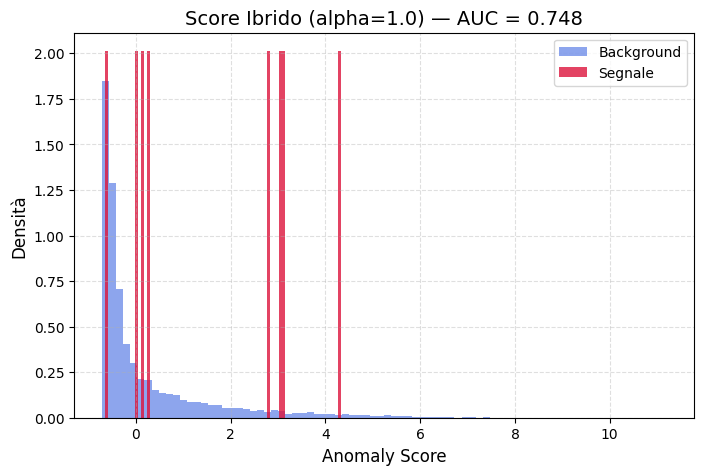

In [ ]:
#@title MODIFICA 1: Score ibrido (ricostruzione pT-pesata + GMM) — NUOVA CELLA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import numpy as np

# Normalizzazione separata dei due score (fondamentale prima di combinarli)
scaler_recon = StandardScaler()
scaler_gmm   = StandardScaler()

recon_bg_scaled       = scaler_recon.fit_transform(recon_scores_bg.reshape(-1, 1)).ravel()
recon_blackbox_scaled = scaler_recon.transform(recon_scores_blackbox.reshape(-1, 1)).ravel()

gmm_bg_scaled       = scaler_gmm.fit_transform((-gmm.score_samples(latent_bg_norm)).reshape(-1, 1)).ravel()
gmm_blackbox_scaled = scaler_gmm.transform((-gmm.score_samples(latent_blackbox_norm)).reshape(-1, 1)).ravel()

# Grid search su alpha per trovare la combinazione migliore
print("Grid search su alpha (ricostruzione vs GMM)...\n")
best_auc_hybrid = 0
best_alpha = 0

for alpha in np.arange(0.0, 1.05, 0.1):
    score = alpha * recon_blackbox_scaled + (1 - alpha) * gmm_blackbox_scaled
    fpr, tpr, _ = roc_curve(true_labels, score)
    roc_auc = auc(fpr, tpr)
    if roc_auc < 0.5:
        roc_auc = 1 - roc_auc
    print(f"  alpha={alpha:.1f} (recon) | AUC = {roc_auc:.4f}")
    if roc_auc > best_auc_hybrid:
        best_auc_hybrid = roc_auc
        best_alpha = alpha

print(f"\n---> MIGLIOR AUC IBRIDO: {best_auc_hybrid:.4f} con alpha={best_alpha:.1f}")

# Plot con il best alpha
best_score = best_alpha * recon_blackbox_scaled + (1 - best_alpha) * gmm_blackbox_scaled
fpr_h, tpr_h, _ = roc_curve(true_labels, best_score)
if auc(fpr_h, tpr_h) < 0.5:
    best_score = -best_score
    fpr_h, tpr_h, _ = roc_curve(true_labels, best_score)

plt.figure(figsize=(8, 5))
plt.hist(best_score[true_labels == 0], bins=80, color='royalblue', alpha=0.6,
         density=True, label='Background')
plt.hist(best_score[true_labels == 1], bins=80, color='crimson', alpha=0.8,
         density=True, label='Segnale')
plt.title(f"Score Ibrido (alpha={best_alpha:.1f}) — AUC = {best_auc_hybrid:.3f}", fontsize=14)
plt.xlabel("Anomaly Score", fontsize=12)
plt.ylabel("Densità", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Ciclo Isolation Forest...

  n_est= 50 | cont=0.01  | AUC = 0.5144
  n_est= 50 | cont=0.05  | AUC = 0.5144
  n_est= 50 | cont=0.1   | AUC = 0.5144
  n_est= 50 | cont=0.2   | AUC = 0.5144
  n_est= 50 | cont=auto  | AUC = 0.5144
  n_est=100 | cont=0.01  | AUC = 0.5027
  n_est=100 | cont=0.05  | AUC = 0.5027
  n_est=100 | cont=0.1   | AUC = 0.5027
  n_est=100 | cont=0.2   | AUC = 0.5027
  n_est=100 | cont=auto  | AUC = 0.5027
  n_est=200 | cont=0.01  | AUC = 0.5098
  n_est=200 | cont=0.05  | AUC = 0.5098
  n_est=200 | cont=0.1   | AUC = 0.5098
  n_est=200 | cont=0.2   | AUC = 0.5098
  n_est=200 | cont=auto  | AUC = 0.5098
  n_est=300 | cont=0.01  | AUC = 0.5158
  n_est=300 | cont=0.05  | AUC = 0.5158
  n_est=300 | cont=0.1   | AUC = 0.5158
  n_est=300 | cont=0.2   | AUC = 0.5158
  n_est=300 | cont=auto  | AUC = 0.5158
  n_est=500 | cont=0.01  | AUC = 0.5115
  n_est=500 | cont=0.05  | AUC = 0.5115
  n_est=500 | cont=0.1   | AUC = 0.5115
  n_est=500 | cont=0.2   | AUC = 0.5115
  n_est=500 |

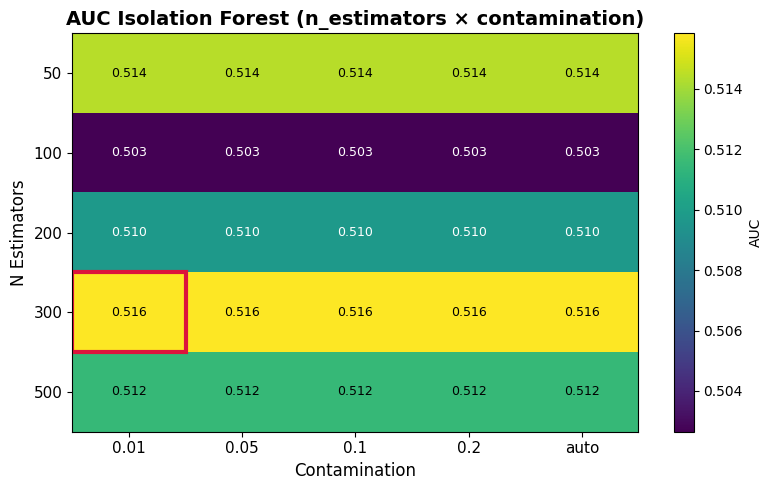

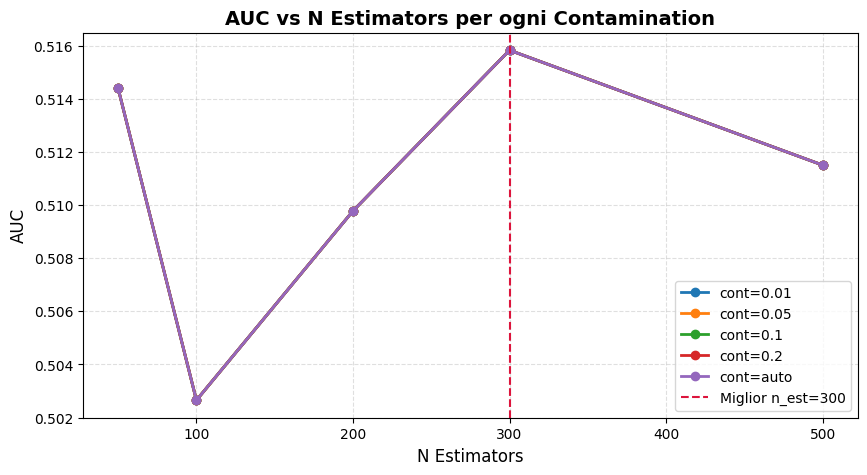

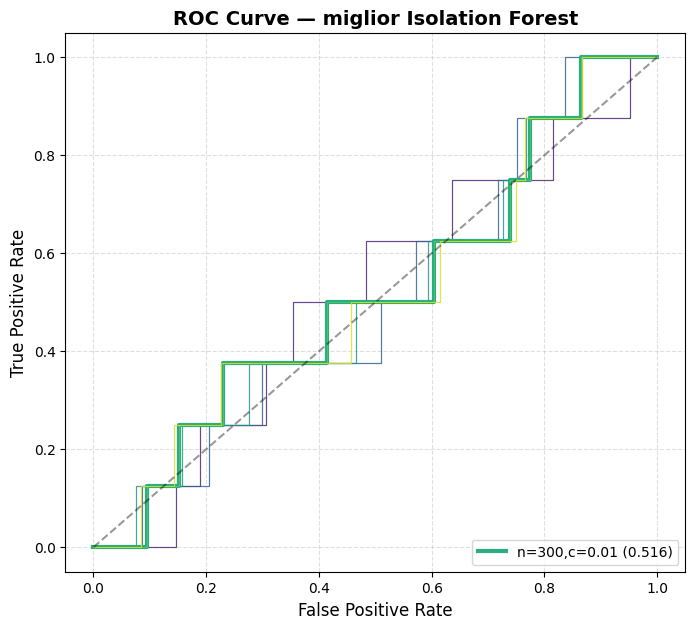

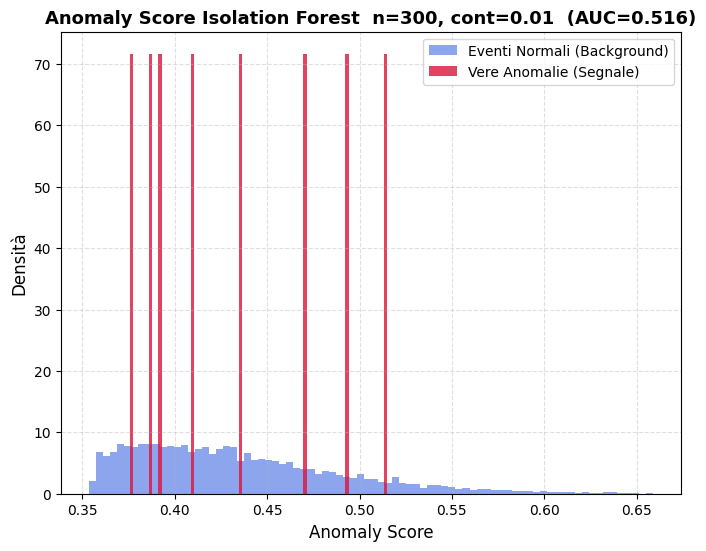

In [ ]:
#@title Isolation Forest: ricerca migliore numero di estimators e contaminazione
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CICLO SU N_ESTIMATORS E CONTAMINAZIONE
# ==========================================
n_estimators_values = [50, 100, 200, 300, 500]
contamination_values = [0.01, 0.05, 0.1, 0.2, 'auto']

results_iso = []

print(f"Ciclo Isolation Forest...\n")

for n_est in n_estimators_values:
    for cont in contamination_values:

        iso = IsolationForest(n_estimators=n_est, contamination=cont, random_state=42, n_jobs=-1)
        iso.fit(latent_bg_norm)

        scores = -iso.score_samples(latent_blackbox_norm)

        fpr, tpr, _ = roc_curve(true_labels, scores)
        roc_auc = auc(fpr, tpr)

        if roc_auc < 0.5:
            roc_auc = 1 - roc_auc
            scores = -scores
            fpr, tpr, _ = roc_curve(true_labels, scores)

        results_iso.append({
            'n_estimators': n_est,
            'contamination': cont,
            'iso': iso,
            'scores': scores,
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc,
        })

        print(f"  n_est={n_est:3d} | cont={str(cont):5s} | AUC = {roc_auc:.4f}")

best_iso = max(results_iso, key=lambda x: x['auc'])
print(f"\n---> MIGLIOR COMBINAZIONE: n_estimators={best_iso['n_estimators']}, "
      f"contamination={best_iso['contamination']} con AUC = {best_iso['auc']:.4f}")

# ==========================================
# PLOT 1: AUC heatmap (n_estimators x contamination)
# ==========================================
import numpy as np

cont_labels = [str(c) for c in contamination_values]
auc_matrix = np.zeros((len(n_estimators_values), len(contamination_values)))

for r in results_iso:
    i = n_estimators_values.index(r['n_estimators'])
    j = contamination_values.index(r['contamination'])
    auc_matrix[i, j] = r['auc']

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(auc_matrix, cmap='viridis', aspect='auto',
               vmin=auc_matrix.min(), vmax=auc_matrix.max())
plt.colorbar(im, ax=ax, label='AUC')

ax.set_xticks(range(len(contamination_values)))
ax.set_xticklabels(cont_labels, fontsize=11)
ax.set_yticks(range(len(n_estimators_values)))
ax.set_yticklabels(n_estimators_values, fontsize=11)
ax.set_xlabel("Contamination", fontsize=12)
ax.set_ylabel("N Estimators", fontsize=12)
ax.set_title("AUC Isolation Forest (n_estimators × contamination)", fontsize=14, fontweight='bold')

# Scrivi il valore AUC in ogni cella
for i in range(len(n_estimators_values)):
    for j in range(len(contamination_values)):
        ax.text(j, i, f"{auc_matrix[i, j]:.3f}", ha='center', va='center',
                color='white' if auc_matrix[i, j] < auc_matrix.mean() else 'black', fontsize=9)

# Evidenzia la cella migliore
best_i = n_estimators_values.index(best_iso['n_estimators'])
best_j = contamination_values.index(best_iso['contamination'])
ax.add_patch(plt.Rectangle((best_j - 0.5, best_i - 0.5), 1, 1,
                             fill=False, edgecolor='crimson', linewidth=3))

plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: AUC vs n_estimators per ogni contamination
# ==========================================
plt.figure(figsize=(10, 5))
for j, cont in enumerate(contamination_values):
    aucs_line = [auc_matrix[i, j] for i in range(len(n_estimators_values))]
    plt.plot(n_estimators_values, aucs_line, marker='o', linewidth=2, label=f"cont={cont}")

plt.axvline(best_iso['n_estimators'], color='crimson', linestyle='--',
            label=f"Miglior n_est={best_iso['n_estimators']}")
plt.xlabel("N Estimators", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.title("AUC vs N Estimators per ogni Contamination", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# ==========================================
# PLOT 3: ROC curve di tutte le combinazioni
# ==========================================
plt.figure(figsize=(8, 7))
cmap = plt.cm.viridis(np.linspace(0, 1, len(results_iso)))

for r, color in zip(results_iso, cmap):
    is_best = (r['n_estimators'] == best_iso['n_estimators'] and
               r['contamination'] == best_iso['contamination'])
    lw    = 3   if is_best else 0.8
    alpha = 1.0 if is_best else 0.3
    plt.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
             label=f"n={r['n_estimators']},c={r['contamination']} ({r['auc']:.3f})" if is_best else None)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — miglior Isolation Forest", fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# ==========================================
# PLOT 4: distribuzione score del miglior modello
# ==========================================
plt.figure(figsize=(8, 6))
plt.hist(best_iso['scores'][true_labels == 0], bins=80, color='royalblue',
         alpha=0.6, density=True, label='Eventi Normali (Background)')
plt.hist(best_iso['scores'][true_labels == 1], bins=80, color='crimson',
         alpha=0.8, density=True, label='Vere Anomalie (Segnale)')
plt.title(f"Anomaly Score Isolation Forest  "
          f"n={best_iso['n_estimators']}, cont={best_iso['contamination']}  "
          f"(AUC={best_iso['auc']:.3f})",
          fontsize=13, fontweight='bold')
plt.xlabel("Anomaly Score", fontsize=12)
plt.ylabel("Densità", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Variabili aggiornate al miglior modello (compatibili col resto del notebook)
iso              = best_iso['iso']
scores_iso       = best_iso['scores']
roc_auc_iso      = best_iso['auc']